In [1]:
# ===========================================================================
# Cell 1 — Imports & data  (now reads the panel WITH the macro-release indicator)
# ===========================================================================
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Aligned daily realized-variance panel + the macro-release indicator column.
# Built in CSVprocessing.ipynb / Download_macro_event_dates.ipynb and merged offline.
data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")

# Target series for the base-case HAR: gold realized variance only
rv = data["RV_gold"].astype(float)
print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"strictly positive: {(rv > 0).all()}  (required for QLIKE and log)")

# --- Macro-release indicator, shifted onto the FORECAST TARGET day -------------
# macro_event[t] == 1 if day t is a scheduled US macro release (FOMC / CPI / PPI / NFP).
# Every design row t holds predictors known at day t and target y[t] = RV_{t+1}.
# To flag whether the DEPENDENT VARIABLE's day (t+1) is a release, the regressor at
# row t must be macro_event[t+1] == macro_event.shift(-1). This is NOT look-ahead:
# release dates are scheduled and publicly known well in advance, so the t+1 flag is
# genuinely known at day t. The indicator enters as a raw 0/1 dummy (never logged).
macro_shifted = data["macro_event"].shift(-1).astype(float)
print(f"\nmacro_event release days in sample: {int(data['macro_event'].sum())} of {len(data)}")
print(f"Sample starts {data.index.min().date()} (macro panel begins 2010-06-08), "
      f"so baseline QLIKEs differ slightly from the original notebook's longer sample.")
rv.describe()


RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
strictly positive: True  (required for QLIKE and log)

macro_event release days in sample: 649 of 4015
Sample starts 2010-06-08 (macro panel begins 2010-06-08), so baseline QLIKEs differ slightly from the original notebook's longer sample.


count    4015.000000
mean       14.466563
std         6.915973
min         4.903504
25%        10.328410
50%        12.941392
75%        16.627784
max       100.986060
Name: RV_gold, dtype: float64

                  n  skewness  excess_kurtosis   JB_stat  JB_pvalue  normal_at_5%
series                                                                           
RV_gold (raw)  4015     3.702             27.5 1.357e+05          0         False
log(RV_gold)   4015    0.7318            1.454     712.2  2.26e-155         False

Interpretation: raw RV_gold rejects normality (JB p=0.00e+00); log(RV_gold) rejects normality (JB p=2.26e-155). Logging sharply reduces skewness/kurtosis toward the normal benchmark.


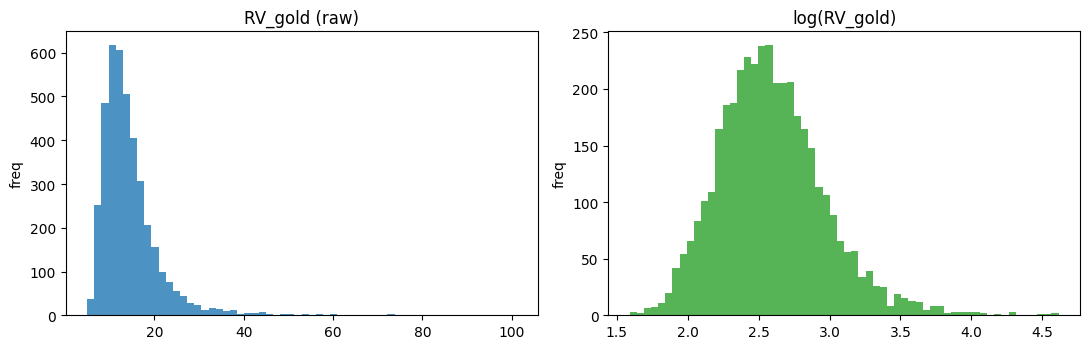

In [2]:
# ===========================================================================
# Cell 2 — Normality analysis of gold RV: raw vs log  (Jarque-Bera, skew, kurt)
# ===========================================================================
# RV is known to be highly right-skewed and leptokurtic; the log transform is
# the standard remedy. Document both with the Jarque-Bera test plus the moments
# that drive it (skewness and EXCESS kurtosis -> both 0 under normality).

def normality_report(x, label):
    x = np.asarray(x, dtype=float)
    jb_stat, jb_p = stats.jarque_bera(x)
    return {
        "series": label,
        "n": x.size,
        "skewness": stats.skew(x),
        "excess_kurtosis": stats.kurtosis(x),     # Fisher: 0 == normal
        "JB_stat": jb_stat,
        "JB_pvalue": jb_p,
        "normal_at_5%": jb_p > 0.05,
    }

log_rv = np.log(rv)

norm_table = pd.DataFrame([
    normality_report(rv,     "RV_gold (raw)"),
    normality_report(log_rv, "log(RV_gold)"),
]).set_index("series")

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(norm_table.to_string())

raw_p, log_p = norm_table.loc["RV_gold (raw)", "JB_pvalue"], norm_table.loc["log(RV_gold)", "JB_pvalue"]
print(
    f"\nInterpretation: raw RV_gold {'rejects' if raw_p < 0.05 else 'does not reject'} normality "
    f"(JB p={raw_p:.2e}); log(RV_gold) {'rejects' if log_p < 0.05 else 'does not reject'} normality "
    f"(JB p={log_p:.2e}). Logging sharply reduces skewness/kurtosis toward the normal benchmark."
)

# Side-by-side histograms
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(rv, bins=60, color="tab:blue", alpha=0.8);  ax[0].set_title("RV_gold (raw)")
ax[1].hist(log_rv, bins=60, color="tab:green", alpha=0.8); ax[1].set_title("log(RV_gold)")
for a in ax: a.set_ylabel("freq")
plt.tight_layout(); plt.show()


In [3]:
# ===========================================================================
# Cell 3 — Build HAR (Corsi 2009) predictors and the 1-day-ahead target
# ===========================================================================
# Predictors known at day t (levels, base case uses gold RV's own history):
#   daily   RV_d[t] = RV_t
#   weekly  RV_w[t] = mean(RV_{t-4..t})    (5-day average)
#   monthly RV_m[t] = mean(RV_{t-21..t})   (22-day average)
# Regression target is next-day RV: y[t] = RV_{t+1}.

har = pd.DataFrame(index=rv.index)
har["RV_d"] = rv
har["RV_w"] = rv.rolling(5).mean()
har["RV_m"] = rv.rolling(22).mean()
har["y"]    = rv.shift(-1)            # one-day-ahead target

# Drop the 21-row monthly warm-up (leading NaNs) and the final row (no t+1 target)
har = har.dropna()

print(f"Usable (X, y) rows: {len(har)}")
print(f"Range: {har.index.min().date()} .. {har.index.max().date()}")
har.head()


Usable (X, y) rows: 3993
Range: 2010-07-08 .. 2026-05-28


,RV_d,RV_w,RV_m,y
Date,,,,
2010-07-08,14.91,18.2,16.27,15.24
2010-07-09,15.24,16.53,16.06,14.75
2010-07-12,14.75,15.98,15.95,13.37
2010-07-13,13.37,14.82,15.8,15.71
2010-07-14,15.71,14.8,15.95,15.21


In [4]:
# ===========================================================================
# Cell 4 — Rolling 1-day-ahead forecasts: direct closed-form OLS per window
# ===========================================================================
# Fixed 500-day rolling estimation window. Plain OLS is closed-form, so each
# step just re-solves the normal equations on its own window (no warm start).

WINDOW = 500

# Design matrix with intercept; rows aligned to `har`.
X_all = np.column_stack([np.ones(len(har)), har[["RV_d", "RV_w", "RV_m"]].to_numpy()])
y_all = har["y"].to_numpy()
dates = har.index

records = []
for t in range(WINDOW, len(har)):
    Xw = X_all[t - WINDOW:t]          # trailing 500 complete (X, y) pairs
    yw = y_all[t - WINDOW:t]
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)   # OLS coefficients
    fcast = X_all[t] @ beta           # forecast of RV_{t+1} from features at day t
    # dates[t] = forecast origin (day t); actual y_all[t] = realized RV one day later
    records.append((dates[t], y_all[t], fcast))

results = pd.DataFrame(records, columns=["origin_date", "actual", "forecast"]).set_index("origin_date")

print(f"Out-of-sample forecasts: {len(results)}")
print(f"OOS origin range: {results.index.min().date()} .. {results.index.max().date()}")
results.head()


Out-of-sample forecasts: 3493
OOS origin range: 2012-06-29 .. 2026-05-28


,actual,forecast
origin_date,,
2012-06-29,12.91,17.74
2012-07-02,11.78,15.08
2012-07-03,17.01,14.27
2012-07-05,20.06,16.64
2012-07-06,10.62,18.14


In [5]:
# ===========================================================================
# Cell 5 — QLIKE loss (Patton 2011, robust form)
# ===========================================================================
#   QLIKE = actual/forecast - log(actual/forecast) - 1   (>= 0, = 0 iff equal)
# Floor non-positive forecasts at eps so the log is defined (count clipped).
EPS = 1e-6

f = results["forecast"].to_numpy()
a = results["actual"].to_numpy()

n_clipped = int((f <= 0).sum())
f_safe = np.maximum(f, EPS)

ratio = a / f_safe
results["qlike"] = ratio - np.log(ratio) - 1.0

avg_qlike = results["qlike"].mean()

print(f"Forecasts clipped to eps={EPS:g}: {n_clipped}")
print(f"All per-day QLIKE >= 0: {(results['qlike'] >= 0).all()}")
print(f"\n>>> Average QLIKE (base-case simple HAR, 500-day rolling, 1-day-ahead): {avg_qlike:.6f}")


Forecasts clipped to eps=1e-06: 0
All per-day QLIKE >= 0: True

>>> Average QLIKE (base-case simple HAR, 500-day rolling, 1-day-ahead): 0.034142


             model: Base HAR-RV (Corsi 2009), levels, own d/w/m lags
        estimation: rolling 500-day window, direct OLS, 1-day-ahead
       n_forecasts: 3493
         oos_start: 2012-06-29
           oos_end: 2026-05-28
 forecasts_clipped: 0
         avg_QLIKE: 0.034142
      median_QLIKE: 0.013313

Spot-check OK: independent refit of final window reproduces last forecast (21.4761).


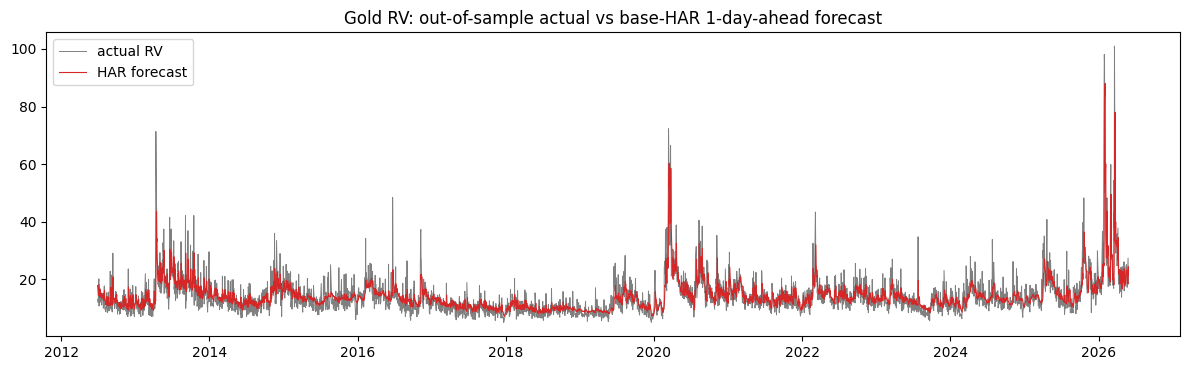

,actual,forecast,qlike
origin_date,,,
2012-06-29,12.91,17.74,0.04548
2012-07-02,11.78,15.08,0.02804
2012-07-03,17.01,14.27,0.01633
2012-07-05,20.06,16.64,0.01863
2012-07-06,10.62,18.14,0.1208


In [6]:
# ===========================================================================
# Cell 6 — Report & sanity checks
# ===========================================================================
summary = {
    "model": "Base HAR-RV (Corsi 2009), levels, own d/w/m lags",
    "estimation": "rolling 500-day window, direct OLS, 1-day-ahead",
    "n_forecasts": len(results),
    "oos_start": results.index.min().date(),
    "oos_end": results.index.max().date(),
    "forecasts_clipped": n_clipped,
    "avg_QLIKE": round(avg_qlike, 6),
    "median_QLIKE": round(results["qlike"].median(), 6),
}
for k, v in summary.items():
    print(f"{k:>18}: {v}")

# Spot-check: refit OLS directly on the final window and confirm last forecast matches
t = len(har) - 1
beta_chk, *_ = np.linalg.lstsq(X_all[t - WINDOW:t], y_all[t - WINDOW:t], rcond=None)
chk = X_all[t] @ beta_chk
assert np.isclose(chk, results["forecast"].iloc[-1]), "final-window refit mismatch"
print(f"\nSpot-check OK: independent refit of final window reproduces last forecast ({chk:.4f}).")

# Actual vs forecast over the out-of-sample period
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(results.index, results["actual"], lw=0.7, label="actual RV", color="0.5")
ax.plot(results.index, results["forecast"], lw=0.8, label="HAR forecast", color="tab:red")
ax.set_title("Gold RV: out-of-sample actual vs base-HAR 1-day-ahead forecast")
ax.legend(); plt.tight_layout(); plt.show()

results.head()


In [7]:
# ===========================================================================
# Cell 7 — log-HAR design table (mean-of-logs specification)
# ===========================================================================
# x = log(RV_gold). HAR components are built on the LOGGED series:
#   daily   x_d[t] = x_t
#   weekly  x_w[t] = mean(x_{t-4..t})
#   monthly x_m[t] = mean(x_{t-21..t})
# Target y_log[t] = x_{t+1} = log(RV_{t+1}). Keep the actual RV level (RV_{t+1})
# aligned for QLIKE, which is always evaluated in variance levels.

x = np.log(rv)

har_log = pd.DataFrame(index=rv.index)
har_log["x_d"]      = x
har_log["x_w"]      = x.rolling(5).mean()
har_log["x_m"]      = x.rolling(22).mean()
har_log["y_log"]    = x.shift(-1)        # log(RV_{t+1})
har_log["y_level"]  = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
har_log = har_log.dropna()

print(f"log-HAR usable rows: {len(har_log)}  (matches levels: {len(har_log) == len(har)})")
har_log.head()


log-HAR usable rows: 3993  (matches levels: True)


,x_d,x_w,x_m,y_log,y_level
Date,,,,,
2010-07-08,2.702,2.888,2.774,2.724,15.24
2010-07-09,2.724,2.8,2.762,2.691,14.75
2010-07-12,2.691,2.767,2.755,2.593,13.37
2010-07-13,2.593,2.694,2.745,2.754,15.71
2010-07-14,2.754,2.693,2.756,2.722,15.21


In [8]:
# ===========================================================================
# Cell 8 — Full-sample inference: classical (homoskedastic) vs HAC (Newey-West)
# ===========================================================================
# Fit each spec on the FULL sample, twice: default OLS SEs and Newey-West HAC.
# Point estimates (and R^2) are identical within a spec; only the SEs/t/p change.
import statsmodels.api as sm

# Newey-West automatic lag rule
n_obs = len(har)
L = int(np.floor(4 * (n_obs / 100) ** (2 / 9)))
print(f"HAC (Newey-West) lag length L = {L}  (rule: floor(4*(n/100)^(2/9)), n={n_obs})\n")

def fit_pair(X, y, names):
    """Return a tidy comparison table: estimate, classical SE/t/p vs HAC SE/t/p."""
    Xc = sm.add_constant(X)
    ols = sm.OLS(y, Xc).fit()
    hac = sm.OLS(y, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    tbl = pd.DataFrame({
        "estimate":  np.asarray(ols.params),
        "SE_classical": np.asarray(ols.bse),
        "t_classical":  np.asarray(ols.tvalues),
        "p_classical":  np.asarray(ols.pvalues),
        "SE_HAC":   np.asarray(hac.bse),
        "t_HAC":    np.asarray(hac.tvalues),
        "p_HAC":    np.asarray(hac.pvalues),
    }, index=names)
    return tbl, ols, hac

# --- Levels HAR ---
lev_tbl, lev_ols, _ = fit_pair(
    har[["RV_d", "RV_w", "RV_m"]].to_numpy(), har["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m"])
# Tie-back: classical params must equal the np.linalg.lstsq beta on the same data
beta_full, *_ = np.linalg.lstsq(X_all, y_all, rcond=None)
assert np.allclose(beta_full, np.asarray(lev_ols.params)), "statsmodels vs lstsq mismatch"

# --- log HAR ---
log_tbl, log_ols, _ = fit_pair(
    har_log[["x_d", "x_w", "x_m"]].to_numpy(), har_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m"])

print(f"LEVELS HAR  (R^2 = {lev_ols.rsquared:.4f}) — classical vs HAC standard errors")
print(lev_tbl.to_string(), "\n")
print(f"LOG HAR     (R^2 = {log_ols.rsquared:.4f}) — classical vs HAC standard errors")
print(log_tbl.to_string())
print("\nNote: within each spec, estimates & R^2 are identical across error assumptions;"
      "\nHAC widens SEs (shrinks t-stats) to account for serial correlation + heteroskedasticity.")


HAC (Newey-West) lag length L = 9  (rule: floor(4*(n/100)^(2/9)), n=3993)

LEVELS HAR  (R^2 = 0.5437) — classical vs HAC standard errors
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const     1.471        0.2305        6.384    1.926e-10  0.3583  4.106 4.026e-05
RV_d     0.4109       0.01837        22.37   1.625e-104 0.06522  6.301  2.96e-10
RV_w     0.3005       0.02857        10.52    1.506e-25 0.05164  5.819 5.922e-09
RV_m     0.1871       0.02575        7.263     4.52e-13 0.04213   4.44 8.986e-06 

LOG HAR     (R^2 = 0.5584) — classical vs HAC standard errors
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    0.2127       0.03675        5.787    7.725e-09 0.04009  5.305 1.125e-07
x_d      0.2703        0.0189         14.3    2.775e-45 0.02862  9.445 3.565e-21
x_w      0.4322       0.03137        13.78    3.116e-42 0.03471  12.45 1.359e-35
x_m      0.2155       0.02767        7.789    8.553e-15 0.03404  6.333

In [9]:
# ===========================================================================
# Cell 9 — Rolling log-HAR QLIKE with Duan's smearing convexity adjustment
# ===========================================================================
# Same 500-day rolling closed-form OLS, but estimated in log space. The naive
# back-transform exp(x_hat) gives the conditional MEDIAN of RV and understates
# the mean (Jensen's inequality). Duan (1983) smearing corrects this
# non-parametrically using the in-window residuals (no normality assumed):
#     RV_hat = exp(x_hat) * mean_i( exp(e_i) ),   e_i = in-window residuals.

Xl_all = np.column_stack([np.ones(len(har_log)), har_log[["x_d", "x_w", "x_m"]].to_numpy()])
yl_all = har_log["y_log"].to_numpy()          # log targets
lvl_all = har_log["y_level"].to_numpy()       # actual RV_{t+1} (levels) for QLIKE
ldates = har_log.index

log_records = []
for t in range(WINDOW, len(har_log)):
    Xw = Xl_all[t - WINDOW:t]
    yw = yl_all[t - WINDOW:t]
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)          # log-space OLS
    resid = yw - Xw @ beta                                   # in-window residuals
    smearing = np.mean(np.exp(resid))                        # Duan smearing factor
    x_hat = Xl_all[t] @ beta                                 # log point forecast
    rv_hat = np.exp(x_hat) * smearing                        # convexity-adjusted level
    log_records.append((ldates[t], lvl_all[t], rv_hat, smearing))

results_log = pd.DataFrame(
    log_records, columns=["origin_date", "actual", "forecast", "smearing"]
).set_index("origin_date")

# QLIKE in variance levels (same Patton form + flooring as Cell 5)
fl = results_log["forecast"].to_numpy()
al = results_log["actual"].to_numpy()
n_clipped_log = int((fl <= 0).sum())
fl_safe = np.maximum(fl, EPS)
ratio_l = al / fl_safe
results_log["qlike"] = ratio_l - np.log(ratio_l) - 1.0
avg_qlike_log = results_log["qlike"].mean()

print(f"log-HAR rolling forecasts: {len(results_log)}")
print(f"Mean Duan smearing factor: {results_log['smearing'].mean():.4f} "
      f"(>1 => upward Jensen correction)")
print(f"Forecasts clipped: {n_clipped_log}")
print(f"\n>>> Average QLIKE (log-HAR + Duan smearing, 500-day rolling): {avg_qlike_log:.6f}")
results_log.head()


log-HAR rolling forecasts: 3493
Mean Duan smearing factor: 1.0332 (>1 => upward Jensen correction)
Forecasts clipped: 0

>>> Average QLIKE (log-HAR + Duan smearing, 500-day rolling): 0.034338


,actual,forecast,smearing,qlike
origin_date,,,,
2012-06-29,12.91,17.65,1.031,0.04406
2012-07-02,11.78,15.16,1.031,0.02919
2012-07-03,17.01,14.46,1.031,0.01387
2012-07-05,20.06,16.72,1.031,0.01764
2012-07-06,10.62,17.97,1.032,0.1171


In [10]:
# ===========================================================================
# Cell 10 — Consolidated results: 4 runs (levels/log x homoskedastic/HAC)
# ===========================================================================
# QLIKE depends only on the point forecasts, so it is INVARIANT to the error
# assumption: homoskedastic and HAC share the same QLIKE within each spec.
# Only the inference (SEs/t/p in Cell 8) differs across error assumptions.

consolidated = pd.DataFrame([
    {"specification": "Levels HAR", "errors": "Homoskedastic (classical)",
     "avg_QLIKE": avg_qlike,     "n_forecasts": len(results),     "clipped": n_clipped},
    {"specification": "Levels HAR", "errors": "HAC (Newey-West)",
     "avg_QLIKE": avg_qlike,     "n_forecasts": len(results),     "clipped": n_clipped},
    {"specification": "Log HAR + Duan smearing", "errors": "Homoskedastic (classical)",
     "avg_QLIKE": avg_qlike_log, "n_forecasts": len(results_log), "clipped": n_clipped_log},
    {"specification": "Log HAR + Duan smearing", "errors": "HAC (Newey-West)",
     "avg_QLIKE": avg_qlike_log, "n_forecasts": len(results_log), "clipped": n_clipped_log},
]).set_index(["specification", "errors"])

print(consolidated.to_string())

best = "Levels HAR" if avg_qlike < avg_qlike_log else "Log HAR + Duan smearing"
print(f"\nDistinct QLIKE values: Levels = {avg_qlike:.6f} | Log+smearing = {avg_qlike_log:.6f}")
print(f"Lower QLIKE (better 1-day-ahead forecast): {best}")
print("\nReminder: the two QLIKE values per spec are identical because the homoskedastic")
print("vs HAC choice changes ONLY coefficient standard errors, not the point forecasts.")


                                                   avg_QLIKE  n_forecasts  clipped
specification           errors                                                    
Levels HAR              Homoskedastic (classical)    0.03414         3493        0
                        HAC (Newey-West)             0.03414         3493        0
Log HAR + Duan smearing Homoskedastic (classical)    0.03434         3493        0
                        HAC (Newey-West)             0.03434         3493        0

Distinct QLIKE values: Levels = 0.034142 | Log+smearing = 0.034338
Lower QLIKE (better 1-day-ahead forecast): Levels HAR

Reminder: the two QLIKE values per spec are identical because the homoskedastic
vs HAC choice changes ONLY coefficient standard errors, not the point forecasts.


In [11]:
# ===========================================================================
# Cell 11 — HAR-X design tables: add GVZ (gold vol index) as exogenous regressor
# ===========================================================================
# GVZ_close at day t is known at the close, so it predicts RV_{t+1} with no
# look-ahead (same alignment as the d/w/m components).
#   Run 5 (levels): add GVZ        -> predict RV_{t+1}
#   Run 6 (log):    add log(GVZ)   -> predict log(RV_{t+1})

har_x = har.copy()
har_x.insert(3, "GVZ", data["GVZ_close"].reindex(har.index))          # day-t level

har_x_log = har_log.copy()
har_x_log.insert(3, "log_GVZ", np.log(data["GVZ_close"]).reindex(har_log.index))

assert har_x.notna().all().all() and har_x_log.notna().all().all(), "unexpected NaNs"
print("Levels HAR-X columns:", list(har_x.columns))
print("Log HAR-X columns:   ", list(har_x_log.columns))
har_x.head()


Levels HAR-X columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'y']
Log HAR-X columns:    ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,GVZ,y
Date,,,,,
2010-07-08,14.91,18.2,16.27,20.26,15.24
2010-07-09,15.24,16.53,16.06,19.68,14.75
2010-07-12,14.75,15.98,15.95,18.51,13.37
2010-07-13,13.37,14.82,15.8,18.99,15.71
2010-07-14,15.71,14.8,15.95,18.24,15.21


In [12]:
# ===========================================================================
# Cell 12 — Full-sample HAR-X inference: classical vs HAC (reuses fit_pair, L=9)
# ===========================================================================
xlev_tbl, xlev_ols, _ = fit_pair(
    har_x[["RV_d", "RV_w", "RV_m", "GVZ"]].to_numpy(), har_x["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ"])

xlog_tbl, xlog_ols, _ = fit_pair(
    har_x_log[["x_d", "x_w", "x_m", "log_GVZ"]].to_numpy(), har_x_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ"])

print(f"LEVELS HAR-X  (R^2 = {xlev_ols.rsquared:.4f}, base levels R^2 = {lev_ols.rsquared:.4f})")
print(xlev_tbl.to_string(), "\n")
print(f"LOG HAR-X     (R^2 = {xlog_ols.rsquared:.4f}, base log R^2 = {log_ols.rsquared:.4f})")
print(xlog_tbl.to_string())

print(f"\nGVZ  (levels) coef = {xlev_tbl.loc['GVZ','estimate']:.4f}, "
      f"HAC t = {xlev_tbl.loc['GVZ','t_HAC']:.2f}, HAC p = {xlev_tbl.loc['GVZ','p_HAC']:.2e}")
print(f"log_GVZ (log) coef = {xlog_tbl.loc['log_GVZ','estimate']:.4f}, "
      f"HAC t = {xlog_tbl.loc['log_GVZ','t_HAC']:.2f}, HAC p = {xlog_tbl.loc['log_GVZ','p_HAC']:.2e}")
print("Adding GVZ raises in-sample R^2 in both specs; check its HAC significance above.")


LEVELS HAR-X  (R^2 = 0.5902, base levels R^2 = 0.5437)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    -1.535        0.2602       -5.898    3.975e-09  0.5266 -2.914  0.003567
RV_d     0.2923       0.01828        15.99    8.276e-56 0.05403   5.41 6.296e-08
RV_w     0.1394       0.02812        4.959    7.398e-07 0.04327  3.222  0.001275
RV_m    -0.2404       0.03162       -7.603     3.58e-14 0.06643 -3.619 0.0002956
GVZ      0.7551       0.03551        21.26     3.82e-95 0.06372  11.85 2.139e-32 

LOG HAR-X     (R^2 = 0.6023, base log R^2 = 0.5584)
         estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const     -0.2323       0.04082       -5.691    1.354e-08 0.04975  -4.67 3.012e-06
x_d        0.1789       0.01846        9.694    5.605e-22 0.02268   7.89 3.027e-15
x_w        0.2343       0.03123        7.501    7.773e-14 0.03503  6.687 2.279e-11
x_m       -0.1606        0.0318        -5.05    4.614e-07 0.04196 -3.828 

In [13]:
# ===========================================================================
# Cell 13 — Rolling HAR-X QLIKE (runs 5 & 6) via reusable helpers
# ===========================================================================
# Generalise the Cell-4 / Cell-9 loops so any feature set can be evaluated.

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_levels_qlike(design, feat_cols, ycol, window=WINDOW):
    """500-day rolling closed-form OLS in levels -> avg QLIKE."""
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    y = design[ycol].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        beta, *_ = np.linalg.lstsq(X[t - window:t], y[t - window:t], rcond=None)
        fc.append(X[t] @ beta); ac.append(y[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

def rolling_log_qlike_smearing(design, feat_cols, ylog_col, ylevel_col, window=WINDOW):
    """500-day rolling log-space OLS + Duan smearing back-transform -> avg QLIKE."""
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Sanity tie-back: helpers reproduce the base-model QLIKEs (no GVZ) ---
base_lev_chk, _, _ = rolling_levels_qlike(har, ["RV_d", "RV_w", "RV_m"], "y")
base_log_chk, _, _ = rolling_log_qlike_smearing(har_log, ["x_d", "x_w", "x_m"], "y_log", "y_level")
assert np.isclose(base_lev_chk, avg_qlike),     f"levels tie-back {base_lev_chk} vs {avg_qlike}"
assert np.isclose(base_log_chk, avg_qlike_log), f"log tie-back {base_log_chk} vs {avg_qlike_log}"
print(f"Tie-back OK: helpers reproduce base QLIKEs ({base_lev_chk:.6f}, {base_log_chk:.6f})\n")

# --- Run 5: Levels HAR-X  &  Run 6: Log HAR-X ---
qlike_x_lev, n_x_lev, clip_x_lev = rolling_levels_qlike(
    har_x, ["RV_d", "RV_w", "RV_m", "GVZ"], "y")
qlike_x_log, n_x_log, clip_x_log = rolling_log_qlike_smearing(
    har_x_log, ["x_d", "x_w", "x_m", "log_GVZ"], "y_log", "y_level")

print(f">>> Run 5  Levels HAR-X (+GVZ)      avg QLIKE = {qlike_x_lev:.6f}  "
      f"(base levels {avg_qlike:.6f}, Δ={qlike_x_lev - avg_qlike:+.6f})")
print(f">>> Run 6  Log HAR-X (+log GVZ)     avg QLIKE = {qlike_x_log:.6f}  "
      f"(base log {avg_qlike_log:.6f}, Δ={qlike_x_log - avg_qlike_log:+.6f})")


Tie-back OK: helpers reproduce base QLIKEs (0.034142, 0.034338)



>>> Run 5  Levels HAR-X (+GVZ)      avg QLIKE = 0.031163  (base levels 0.034142, Δ=-0.002980)
>>> Run 6  Log HAR-X (+log GVZ)     avg QLIKE = 0.030474  (base log 0.034338, Δ=-0.003863)


In [14]:
# ===========================================================================
# Cell 14 — Final consolidated results: all 6 runs
# ===========================================================================
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.
# Runs 1-4 therefore collapse to 2 distinct QLIKEs; runs 5-6 add GVZ.

all_runs = pd.DataFrame([
    {"run": 1, "model": "Levels HAR",        "errors": "Homoskedastic", "avg_QLIKE": avg_qlike},
    {"run": 2, "model": "Levels HAR",        "errors": "HAC",           "avg_QLIKE": avg_qlike},
    {"run": 3, "model": "Log HAR (+smear)",  "errors": "Homoskedastic", "avg_QLIKE": avg_qlike_log},
    {"run": 4, "model": "Log HAR (+smear)",  "errors": "HAC",           "avg_QLIKE": avg_qlike_log},
    {"run": 5, "model": "Levels HAR-X +GVZ", "errors": "Homosk & HAC",  "avg_QLIKE": qlike_x_lev},
    {"run": 6, "model": "Log HAR-X +logGVZ", "errors": "Homosk & HAC",  "avg_QLIKE": qlike_x_log},
]).set_index("run")

print(all_runs.to_string())

best = all_runs["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs.loc[best, 'avg_QLIKE']:.6f})")
print("\nGVZ marginal effect (lower QLIKE = better):")
print(f"  Levels: {avg_qlike:.6f} -> {qlike_x_lev:.6f}  (Δ {qlike_x_lev - avg_qlike:+.6f})")
print(f"  Log:    {avg_qlike_log:.6f} -> {qlike_x_log:.6f}  (Δ {qlike_x_log - avg_qlike_log:+.6f})")
print("\nNote: within runs 1-4, homoskedastic vs HAC share an identical QLIKE — the error")
print("assumption affects only the inference tables (Cells 8/12), never the forecasts.")


                 model         errors  avg_QLIKE
run                                             
1           Levels HAR  Homoskedastic    0.03414
2           Levels HAR            HAC    0.03414
3     Log HAR (+smear)  Homoskedastic    0.03434
4     Log HAR (+smear)            HAC    0.03434
5    Levels HAR-X +GVZ   Homosk & HAC    0.03116
6    Log HAR-X +logGVZ   Homosk & HAC    0.03047

Best model: run 6 — Log HAR-X +logGVZ (avg QLIKE = 0.030474)

GVZ marginal effect (lower QLIKE = better):
  Levels: 0.034142 -> 0.031163  (Δ -0.002980)
  Log:    0.034338 -> 0.030474  (Δ -0.003863)

Note: within runs 1-4, homoskedastic vs HAC share an identical QLIKE — the error
assumption affects only the inference tables (Cells 8/12), never the forecasts.


In [15]:
# ===========================================================================
# Cell 15 — HAR-X design tables: add SPX (S&P 500 E-mini) RV as exogenous term
# ===========================================================================
# RV_ES at day t is the equity-market realized variance, known at the close, so
# it predicts gold RV_{t+1} with no look-ahead (same alignment as GVZ / d-w-m).
# Mirroring the GVZ treatment, SPX RV enters as a SINGLE contemporaneous day-t
# term (not its own d/w/m decomposition).
#   Run 7  (levels):  + RV_ES                 -> predict RV_{t+1}
#   Run 8  (log):     + log(RV_ES)            -> predict log(RV_{t+1})
#   Run 9  (levels):  + RV_ES + GVZ           -> predict RV_{t+1}
#   Run 10 (log):     + log(RV_ES) + log(GVZ) -> predict log(RV_{t+1})

# RV_ES must be strictly positive for the log transform (same requirement as RV_gold)
assert (data["RV_ES"] > 0).all(), "RV_ES has non-positive values; log transform undefined"
print(f"RV_ES strictly positive: {(data['RV_ES'] > 0).all()}  (required for log runs)")

# --- Levels designs: extend base HAR (Cell 3) and HAR-X+GVZ (Cell 11) ---
har_spx = har.copy()
har_spx.insert(3, "RV_ES", data["RV_ES"].reindex(har.index))                 # day-t level

har_spx_gvz = har_x.copy()                                                    # already has GVZ
har_spx_gvz.insert(4, "RV_ES", data["RV_ES"].reindex(har_x.index))

# --- Log designs: extend log HAR (Cell 7) and log HAR-X+GVZ (Cell 11) ---
har_spx_log = har_log.copy()
har_spx_log.insert(3, "log_RV_ES", np.log(data["RV_ES"]).reindex(har_log.index))

har_spx_gvz_log = har_x_log.copy()                                           # already has log_GVZ
har_spx_gvz_log.insert(4, "log_RV_ES", np.log(data["RV_ES"]).reindex(har_x_log.index))

for name, df in [("har_spx", har_spx), ("har_spx_gvz", har_spx_gvz),
                 ("har_spx_log", har_spx_log), ("har_spx_gvz_log", har_spx_gvz_log)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 7  Levels +SPX        columns:", list(har_spx.columns))
print("Run 8  Log    +SPX        columns:", list(har_spx_log.columns))
print("Run 9  Levels +SPX +GVZ   columns:", list(har_spx_gvz.columns))
print("Run 10 Log    +SPX +GVZ   columns:", list(har_spx_gvz_log.columns))
har_spx.head()


RV_ES strictly positive: True  (required for log runs)
Run 7  Levels +SPX        columns: ['RV_d', 'RV_w', 'RV_m', 'RV_ES', 'y']
Run 8  Log    +SPX        columns: ['x_d', 'x_w', 'x_m', 'log_RV_ES', 'y_log', 'y_level']
Run 9  Levels +SPX +GVZ   columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'RV_ES', 'y']
Run 10 Log    +SPX +GVZ   columns: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,RV_ES,y
Date,,,,,
2010-07-08,14.91,18.2,16.27,19.08,15.24
2010-07-09,15.24,16.53,16.06,14.67,14.75
2010-07-12,14.75,15.98,15.95,16.1,13.37
2010-07-13,13.37,14.82,15.8,18.65,15.71
2010-07-14,15.71,14.8,15.95,18.41,15.21


In [16]:
# ===========================================================================
# Cell 16 — Full-sample SPX HAR-X inference: classical vs HAC (reuses fit_pair)
# ===========================================================================
# Run 7 baseline = run 1 (levels HAR); Run 9 baseline = run 5 (levels HAR-X +GVZ).
# Run 8 baseline = run 3 (log HAR);    Run 10 baseline = run 6 (log HAR-X +logGVZ).

# Run 7: Levels HAR + SPX RV
s7_tbl, s7_ols, _ = fit_pair(
    har_spx[["RV_d", "RV_w", "RV_m", "RV_ES"]].to_numpy(), har_spx["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "RV_ES"])

# Run 9: Levels HAR + SPX RV + GVZ
s9_tbl, s9_ols, _ = fit_pair(
    har_spx_gvz[["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"]].to_numpy(), har_spx_gvz["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"])

# Run 8: Log HAR + SPX log RV
s8_tbl, s8_ols, _ = fit_pair(
    har_spx_log[["x_d", "x_w", "x_m", "log_RV_ES"]].to_numpy(), har_spx_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_RV_ES"])

# Run 10: Log HAR + SPX log RV + log GVZ
s10_tbl, s10_ols, _ = fit_pair(
    har_spx_gvz_log[["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]].to_numpy(),
    har_spx_gvz_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"])

print(f"RUN 7  LEVELS HAR +SPX        (R^2 = {s7_ols.rsquared:.4f}, base run1 = {lev_ols.rsquared:.4f})")
print(s7_tbl.to_string(), "\n")
print(f"RUN 9  LEVELS HAR +SPX +GVZ   (R^2 = {s9_ols.rsquared:.4f}, base run5 = {xlev_ols.rsquared:.4f})")
print(s9_tbl.to_string(), "\n")
print(f"RUN 8  LOG HAR +SPX           (R^2 = {s8_ols.rsquared:.4f}, base run3 = {log_ols.rsquared:.4f})")
print(s8_tbl.to_string(), "\n")
print(f"RUN 10 LOG HAR +SPX +logGVZ   (R^2 = {s10_ols.rsquared:.4f}, base run6 = {xlog_ols.rsquared:.4f})")
print(s10_tbl.to_string())

print(f"\nSPX RV significance (HAC):")
print(f"  Run 7  RV_ES        coef = {s7_tbl.loc['RV_ES','estimate']:.4f}, "
      f"t = {s7_tbl.loc['RV_ES','t_HAC']:.2f}, p = {s7_tbl.loc['RV_ES','p_HAC']:.2e}")
print(f"  Run 9  RV_ES        coef = {s9_tbl.loc['RV_ES','estimate']:.4f}, "
      f"t = {s9_tbl.loc['RV_ES','t_HAC']:.2f}, p = {s9_tbl.loc['RV_ES','p_HAC']:.2e}")
print(f"  Run 8  log_RV_ES    coef = {s8_tbl.loc['log_RV_ES','estimate']:.4f}, "
      f"t = {s8_tbl.loc['log_RV_ES','t_HAC']:.2f}, p = {s8_tbl.loc['log_RV_ES','p_HAC']:.2e}")
print(f"  Run 10 log_RV_ES    coef = {s10_tbl.loc['log_RV_ES','estimate']:.4f}, "
      f"t = {s10_tbl.loc['log_RV_ES','t_HAC']:.2f}, p = {s10_tbl.loc['log_RV_ES','p_HAC']:.2e}")


RUN 7  LEVELS HAR +SPX        (R^2 = 0.5458, base run1 = 0.5437)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const     1.329        0.2324        5.718    1.156e-08  0.3563  3.729 0.0001922
RV_d      0.392       0.01886        20.78    3.637e-91 0.07384  5.308 1.107e-07
RV_w     0.2872       0.02867        10.02    2.456e-23 0.04431   6.48 9.143e-11
RV_m     0.1924       0.02573        7.479     9.13e-14 0.04296  4.479  7.49e-06
RV_ES   0.03847      0.008999        4.275    1.953e-05  0.0263  1.463    0.1435 

RUN 9  LEVELS HAR +SPX +GVZ   (R^2 = 0.5905, base run5 = 0.5902)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    -1.556        0.2604       -5.975    2.498e-09  0.5118 -3.041   0.00236
RV_d     0.2864       0.01861        15.39    5.808e-52 0.06197  4.622 3.802e-06
RV_w     0.1361       0.02818        4.831    1.411e-06  0.0428  3.181   0.00147
RV_m    -0.2339       0.03186       -7.341    2.548e-13 0.

In [17]:
# ===========================================================================
# Cell 17 — Rolling 1-day-ahead QLIKE for SPX runs 7-10 (reuses Cell-13 helpers)
# ===========================================================================
# Same 500-day rolling closed-form OLS (levels) / log-space OLS + Duan smearing.

# Run 7: Levels HAR + SPX RV
qlike_s7, n_s7, clip_s7 = rolling_levels_qlike(
    har_spx, ["RV_d", "RV_w", "RV_m", "RV_ES"], "y")
# Run 8: Log HAR + SPX log RV
qlike_s8, n_s8, clip_s8 = rolling_log_qlike_smearing(
    har_spx_log, ["x_d", "x_w", "x_m", "log_RV_ES"], "y_log", "y_level")
# Run 9: Levels HAR + SPX RV + GVZ
qlike_s9, n_s9, clip_s9 = rolling_levels_qlike(
    har_spx_gvz, ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"], "y")
# Run 10: Log HAR + SPX log RV + log GVZ
qlike_s10, n_s10, clip_s10 = rolling_log_qlike_smearing(
    har_spx_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"], "y_log", "y_level")

print(f">>> Run 7  Levels HAR +SPX           avg QLIKE = {qlike_s7:.6f}  "
      f"(base run1 {avg_qlike:.6f}, Δ={qlike_s7 - avg_qlike:+.6f})")
print(f">>> Run 8  Log HAR +SPX              avg QLIKE = {qlike_s8:.6f}  "
      f"(base run3 {avg_qlike_log:.6f}, Δ={qlike_s8 - avg_qlike_log:+.6f})")
print(f">>> Run 9  Levels HAR +SPX +GVZ      avg QLIKE = {qlike_s9:.6f}  "
      f"(base run5 {qlike_x_lev:.6f}, Δ={qlike_s9 - qlike_x_lev:+.6f})")
print(f">>> Run 10 Log HAR +SPX +logGVZ      avg QLIKE = {qlike_s10:.6f}  "
      f"(base run6 {qlike_x_log:.6f}, Δ={qlike_s10 - qlike_x_log:+.6f})")


>>> Run 7  Levels HAR +SPX           avg QLIKE = 0.034463  (base run1 0.034142, Δ=+0.000321)
>>> Run 8  Log HAR +SPX              avg QLIKE = 0.034454  (base run3 0.034338, Δ=+0.000116)
>>> Run 9  Levels HAR +SPX +GVZ      avg QLIKE = 0.031353  (base run5 0.031163, Δ=+0.000190)
>>> Run 10 Log HAR +SPX +logGVZ      avg QLIKE = 0.030623  (base run6 0.030474, Δ=+0.000149)


In [18]:
# ===========================================================================
# Cell 18 — Final consolidated results: all 10 runs
# ===========================================================================
# Runs 1-6 as before; runs 7-10 add SPX (S&P 500 E-mini) RV as a day-t term.
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.

all_runs_full = pd.DataFrame([
    {"run": 1,  "model": "Levels HAR",                "errors": "Homosk & HAC", "avg_QLIKE": avg_qlike},
    {"run": 2,  "model": "Log HAR (+smear)",          "errors": "Homosk & HAC", "avg_QLIKE": avg_qlike_log},
    {"run": 3,  "model": "Levels HAR-X +GVZ",         "errors": "Homosk & HAC", "avg_QLIKE": qlike_x_lev},
    {"run": 4,  "model": "Log HAR-X +logGVZ",         "errors": "Homosk & HAC", "avg_QLIKE": qlike_x_log},
    {"run": 7,  "model": "Levels HAR +SPX",           "errors": "Homosk & HAC", "avg_QLIKE": qlike_s7},
    {"run": 8,  "model": "Log HAR +SPX",              "errors": "Homosk & HAC", "avg_QLIKE": qlike_s8},
    {"run": 9,  "model": "Levels HAR +SPX +GVZ",      "errors": "Homosk & HAC", "avg_QLIKE": qlike_s9},
    {"run": 10, "model": "Log HAR +SPX +logGVZ",      "errors": "Homosk & HAC", "avg_QLIKE": qlike_s10},
]).set_index("run").sort_values("avg_QLIKE")

print("All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):")
print(all_runs_full.to_string())

best = all_runs_full["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs_full.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs_full.loc[best, 'avg_QLIKE']:.6f})")

print("\nSPX RV marginal effect (lower QLIKE = better):")
print(f"  Levels base:  {avg_qlike:.6f} -> +SPX {qlike_s7:.6f}  (Δ {qlike_s7 - avg_qlike:+.6f})")
print(f"  Log    base:  {avg_qlike_log:.6f} -> +SPX {qlike_s8:.6f}  (Δ {qlike_s8 - avg_qlike_log:+.6f})")
print(f"  Levels +GVZ:  {qlike_x_lev:.6f} -> +SPX {qlike_s9:.6f}  (Δ {qlike_s9 - qlike_x_lev:+.6f})")
print(f"  Log    +GVZ:  {qlike_x_log:.6f} -> +SPX {qlike_s10:.6f}  (Δ {qlike_s10 - qlike_x_log:+.6f})")


All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):
                    model        errors  avg_QLIKE
run                                               
4       Log HAR-X +logGVZ  Homosk & HAC    0.03047
10   Log HAR +SPX +logGVZ  Homosk & HAC    0.03062
3       Levels HAR-X +GVZ  Homosk & HAC    0.03116
9    Levels HAR +SPX +GVZ  Homosk & HAC    0.03135
1              Levels HAR  Homosk & HAC    0.03414
2        Log HAR (+smear)  Homosk & HAC    0.03434
8            Log HAR +SPX  Homosk & HAC    0.03445
7         Levels HAR +SPX  Homosk & HAC    0.03446

Best model: run 4 — Log HAR-X +logGVZ (avg QLIKE = 0.030474)

SPX RV marginal effect (lower QLIKE = better):
  Levels base:  0.034142 -> +SPX 0.034463  (Δ +0.000321)
  Log    base:  0.034338 -> +SPX 0.034454  (Δ +0.000116)
  Levels +GVZ:  0.031163 -> +SPX 0.031353  (Δ +0.000190)
  Log    +GVZ:  0.030474 -> +SPX 0.030623  (Δ +0.000149)


In [19]:
# ===========================================================================
# Cell 19 — HAR-X design tables: add crude-oil (CL) RV as exogenous term
# ===========================================================================
# RV_crude at day t is crude-oil realized variance, known at the close, so it
# predicts gold RV_{t+1} with no look-ahead (same alignment as GVZ / SPX / d-w-m).
# Mirroring GVZ and SPX, crude RV enters as a SINGLE contemporaneous day-t term.
#   Run 11 (levels):  + RV_crude                 -> predict RV_{t+1}
#   Run 12 (log):     + log(RV_crude)            -> predict log(RV_{t+1})
#   Run 13 (levels):  + RV_crude + GVZ           -> predict RV_{t+1}
#   Run 14 (log):     + log(RV_crude) + log(GVZ) -> predict log(RV_{t+1})

# RV_crude must be strictly positive for the log transform
assert (data["RV_crude"] > 0).all(), "RV_crude has non-positive values; log undefined"
print(f"RV_crude strictly positive: {(data['RV_crude'] > 0).all()}  (required for log runs)")

# --- Levels designs: extend base HAR (Cell 3) and HAR-X+GVZ (Cell 11) ---
har_cl = har.copy()
har_cl.insert(3, "RV_crude", data["RV_crude"].reindex(har.index))            # day-t level

har_cl_gvz = har_x.copy()                                                     # already has GVZ
har_cl_gvz.insert(4, "RV_crude", data["RV_crude"].reindex(har_x.index))

# --- Log designs: extend log HAR (Cell 7) and log HAR-X+GVZ (Cell 11) ---
har_cl_log = har_log.copy()
har_cl_log.insert(3, "log_RV_crude", np.log(data["RV_crude"]).reindex(har_log.index))

har_cl_gvz_log = har_x_log.copy()                                            # already has log_GVZ
har_cl_gvz_log.insert(4, "log_RV_crude", np.log(data["RV_crude"]).reindex(har_x_log.index))

for name, df in [("har_cl", har_cl), ("har_cl_gvz", har_cl_gvz),
                 ("har_cl_log", har_cl_log), ("har_cl_gvz_log", har_cl_gvz_log)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 11 Levels +crude      columns:", list(har_cl.columns))
print("Run 12 Log    +crude      columns:", list(har_cl_log.columns))
print("Run 13 Levels +crude +GVZ columns:", list(har_cl_gvz.columns))
print("Run 14 Log    +crude +GVZ columns:", list(har_cl_gvz_log.columns))
har_cl.head()


RV_crude strictly positive: True  (required for log runs)
Run 11 Levels +crude      columns: ['RV_d', 'RV_w', 'RV_m', 'RV_crude', 'y']
Run 12 Log    +crude      columns: ['x_d', 'x_w', 'x_m', 'log_RV_crude', 'y_log', 'y_level']
Run 13 Levels +crude +GVZ columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'RV_crude', 'y']
Run 14 Log    +crude +GVZ columns: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,RV_crude,y
Date,,,,,
2010-07-08,14.91,18.2,16.27,27.32,15.24
2010-07-09,15.24,16.53,16.06,22.63,14.75
2010-07-12,14.75,15.98,15.95,27.97,13.37
2010-07-13,13.37,14.82,15.8,26.06,15.71
2010-07-14,15.71,14.8,15.95,28.26,15.21


In [20]:
# ===========================================================================
# Cell 20 — Full-sample crude HAR-X inference: classical vs HAC (reuses fit_pair)
# ===========================================================================
# Run 11 baseline = run 1 (levels HAR);  Run 13 baseline = run 5 (levels +GVZ).
# Run 12 baseline = run 3 (log HAR);     Run 14 baseline = run 6 (log +logGVZ).

# Run 11: Levels HAR + crude RV
c11_tbl, c11_ols, _ = fit_pair(
    har_cl[["RV_d", "RV_w", "RV_m", "RV_crude"]].to_numpy(), har_cl["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "RV_crude"])

# Run 13: Levels HAR + crude RV + GVZ
c13_tbl, c13_ols, _ = fit_pair(
    har_cl_gvz[["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"]].to_numpy(), har_cl_gvz["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"])

# Run 12: Log HAR + crude log RV
c12_tbl, c12_ols, _ = fit_pair(
    har_cl_log[["x_d", "x_w", "x_m", "log_RV_crude"]].to_numpy(), har_cl_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_RV_crude"])

# Run 14: Log HAR + crude log RV + log GVZ
c14_tbl, c14_ols, _ = fit_pair(
    har_cl_gvz_log[["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]].to_numpy(),
    har_cl_gvz_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"])

print(f"RUN 11 LEVELS HAR +crude       (R^2 = {c11_ols.rsquared:.4f}, base run1 = {lev_ols.rsquared:.4f})")
print(c11_tbl.to_string(), "\n")
print(f"RUN 13 LEVELS HAR +crude +GVZ  (R^2 = {c13_ols.rsquared:.4f}, base run5 = {xlev_ols.rsquared:.4f})")
print(c13_tbl.to_string(), "\n")
print(f"RUN 12 LOG HAR +crude          (R^2 = {c12_ols.rsquared:.4f}, base run3 = {log_ols.rsquared:.4f})")
print(c12_tbl.to_string(), "\n")
print(f"RUN 14 LOG HAR +crude +logGVZ  (R^2 = {c14_ols.rsquared:.4f}, base run6 = {xlog_ols.rsquared:.4f})")
print(c14_tbl.to_string())

print(f"\ncrude RV significance (HAC):")
print(f"  Run 11 RV_crude       coef = {c11_tbl.loc['RV_crude','estimate']:.4f}, "
      f"t = {c11_tbl.loc['RV_crude','t_HAC']:.2f}, p = {c11_tbl.loc['RV_crude','p_HAC']:.2e}")
print(f"  Run 13 RV_crude       coef = {c13_tbl.loc['RV_crude','estimate']:.4f}, "
      f"t = {c13_tbl.loc['RV_crude','t_HAC']:.2f}, p = {c13_tbl.loc['RV_crude','p_HAC']:.2e}")
print(f"  Run 12 log_RV_crude   coef = {c12_tbl.loc['log_RV_crude','estimate']:.4f}, "
      f"t = {c12_tbl.loc['log_RV_crude','t_HAC']:.2f}, p = {c12_tbl.loc['log_RV_crude','p_HAC']:.2e}")
print(f"  Run 14 log_RV_crude   coef = {c14_tbl.loc['log_RV_crude','estimate']:.4f}, "
      f"t = {c14_tbl.loc['log_RV_crude','t_HAC']:.2f}, p = {c14_tbl.loc['log_RV_crude','p_HAC']:.2e}")


RUN 11 LEVELS HAR +crude       (R^2 = 0.5438, base run1 = 0.5437)
          estimate  SE_classical  t_classical  p_classical  SE_HAC   t_HAC     p_HAC
const        1.475        0.2307        6.394    1.806e-10   0.355   4.154  3.26e-05
RV_d        0.4118        0.0185        22.26   1.531e-103 0.06631    6.21 5.302e-10
RV_w        0.3004       0.02857        10.51    1.596e-25 0.05201   5.776 7.672e-09
RV_m        0.1885       0.02603        7.243     5.24e-13 0.04294   4.391 1.129e-05
RV_crude -0.001097      0.002782      -0.3942       0.6934 0.00389 -0.2819     0.778 

RUN 13 LEVELS HAR +crude +GVZ  (R^2 = 0.5903, base run5 = 0.5902)
          estimate  SE_classical  t_classical  p_classical   SE_HAC   t_HAC     p_HAC
const        -1.53        0.2603       -5.878    4.501e-09   0.5232  -2.924  0.003457
RV_d        0.2939       0.01839        15.98    8.936e-56  0.05543   5.302 1.144e-07
RV_w        0.1391       0.02812        4.946    7.896e-07  0.04351   3.196  0.001391
RV_m       -

In [21]:
# ===========================================================================
# Cell 21 — Rolling 1-day-ahead QLIKE for crude runs 11-14 (Cell-13 helpers)
# ===========================================================================
# Run 11: Levels HAR + crude RV
qlike_c11, n_c11, clip_c11 = rolling_levels_qlike(
    har_cl, ["RV_d", "RV_w", "RV_m", "RV_crude"], "y")
# Run 12: Log HAR + crude log RV
qlike_c12, n_c12, clip_c12 = rolling_log_qlike_smearing(
    har_cl_log, ["x_d", "x_w", "x_m", "log_RV_crude"], "y_log", "y_level")
# Run 13: Levels HAR + crude RV + GVZ
qlike_c13, n_c13, clip_c13 = rolling_levels_qlike(
    har_cl_gvz, ["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"], "y")
# Run 14: Log HAR + crude log RV + log GVZ
qlike_c14, n_c14, clip_c14 = rolling_log_qlike_smearing(
    har_cl_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"], "y_log", "y_level")

print(f">>> Run 11 Levels HAR +crude         avg QLIKE = {qlike_c11:.6f}  "
      f"(base run1 {avg_qlike:.6f}, Δ={qlike_c11 - avg_qlike:+.6f})")
print(f">>> Run 12 Log HAR +crude            avg QLIKE = {qlike_c12:.6f}  "
      f"(base run3 {avg_qlike_log:.6f}, Δ={qlike_c12 - avg_qlike_log:+.6f})")
print(f">>> Run 13 Levels HAR +crude +GVZ    avg QLIKE = {qlike_c13:.6f}  "
      f"(base run5 {qlike_x_lev:.6f}, Δ={qlike_c13 - qlike_x_lev:+.6f})")
print(f">>> Run 14 Log HAR +crude +logGVZ    avg QLIKE = {qlike_c14:.6f}  "
      f"(base run6 {qlike_x_log:.6f}, Δ={qlike_c14 - qlike_x_log:+.6f})")


>>> Run 11 Levels HAR +crude         avg QLIKE = 0.034245  (base run1 0.034142, Δ=+0.000102)
>>> Run 12 Log HAR +crude            avg QLIKE = 0.034301  (base run3 0.034338, Δ=-0.000037)
>>> Run 13 Levels HAR +crude +GVZ    avg QLIKE = 0.031377  (base run5 0.031163, Δ=+0.000214)
>>> Run 14 Log HAR +crude +logGVZ    avg QLIKE = 0.030511  (base run6 0.030474, Δ=+0.000037)


In [22]:
# ===========================================================================
# Cell 21b — All-four-predictor designs (runs 15 & 16): HAR + GVZ + SPX + crude
# ===========================================================================
# Combine every exogenous block on top of the base gold HAR. Build on the
# existing +crude+GVZ designs (Cell 19) and insert the remaining SPX term, so
# the column order stays consistent with the rest of the notebook.
#   Run 15 (levels):  RV_d,RV_w,RV_m + GVZ + RV_ES + RV_crude        -> RV_{t+1}
#   Run 16 (log):     x_d,x_w,x_m + log_GVZ + log_RV_ES + log_RV_crude -> log RV_{t+1}

# --- Levels design (extend har_cl_gvz: has RV_d,RV_w,RV_m,GVZ,RV_crude) ---
har_all = har_cl_gvz.copy()
har_all.insert(4, "RV_ES", data["RV_ES"].reindex(har_cl_gvz.index))          # day-t level

# --- Log design (extend har_cl_gvz_log: has x_d,x_w,x_m,log_GVZ,log_RV_crude) ---
har_all_log = har_cl_gvz_log.copy()
har_all_log.insert(4, "log_RV_ES", np.log(data["RV_ES"]).reindex(har_cl_gvz_log.index))

for name, df in [("har_all", har_all), ("har_all_log", har_all_log)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 15 Levels +GVZ+SPX+crude columns:", list(har_all.columns))
print("Run 16 Log    +GVZ+SPX+crude columns:", list(har_all_log.columns))
har_all.head()


Run 15 Levels +GVZ+SPX+crude columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'RV_ES', 'RV_crude', 'y']
Run 16 Log    +GVZ+SPX+crude columns: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'log_RV_crude', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,GVZ,RV_ES,RV_crude,y
Date,,,,,,,
2010-07-08,14.91,18.2,16.27,20.26,19.08,27.32,15.24
2010-07-09,15.24,16.53,16.06,19.68,14.67,22.63,14.75
2010-07-12,14.75,15.98,15.95,18.51,16.1,27.97,13.37
2010-07-13,13.37,14.82,15.8,18.99,18.65,26.06,15.71
2010-07-14,15.71,14.8,15.95,18.24,18.41,28.26,15.21


In [23]:
# ===========================================================================
# Cell 21c — Rolling 1-day-ahead QLIKE for the all-four runs 15 & 16
# ===========================================================================
# Run 15: Levels HAR + GVZ + SPX + crude
qlike_all_lev, n_all_lev, clip_all_lev = rolling_levels_qlike(
    har_all, ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES", "RV_crude"], "y")
# Run 16: Log HAR + log GVZ + log SPX + log crude
qlike_all_log, n_all_log, clip_all_log = rolling_log_qlike_smearing(
    har_all_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "log_RV_crude"], "y_log", "y_level")

print(f">>> Run 15 Levels HAR +GVZ+SPX+crude   avg QLIKE = {qlike_all_lev:.6f}  "
      f"(best 2-var levels run9 {qlike_s9:.6f}, Δ={qlike_all_lev - qlike_s9:+.6f})")
print(f">>> Run 16 Log    HAR +GVZ+SPX+crude   avg QLIKE = {qlike_all_log:.6f}  "
      f"(best 2-var log run10 {qlike_s10:.6f}, Δ={qlike_all_log - qlike_s10:+.6f})")


>>> Run 15 Levels HAR +GVZ+SPX+crude   avg QLIKE = 0.031417  (best 2-var levels run9 0.031353, Δ=+0.000064)
>>> Run 16 Log    HAR +GVZ+SPX+crude   avg QLIKE = 0.030662  (best 2-var log run10 0.030623, Δ=+0.000039)


In [24]:
# ===========================================================================
# Cell 22 — Final consolidated results: all 16 runs (gold + GVZ + SPX + crude + combined)
# ===========================================================================
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.

all_runs_16 = pd.DataFrame([
    {"run": 1,  "model": "Levels HAR",                "avg_QLIKE": avg_qlike},
    {"run": 2,  "model": "Log HAR (+smear)",          "avg_QLIKE": avg_qlike_log},
    {"run": 3,  "model": "Levels HAR-X +GVZ",         "avg_QLIKE": qlike_x_lev},
    {"run": 4,  "model": "Log HAR-X +logGVZ",         "avg_QLIKE": qlike_x_log},
    {"run": 7,  "model": "Levels HAR +SPX",           "avg_QLIKE": qlike_s7},
    {"run": 8,  "model": "Log HAR +SPX",              "avg_QLIKE": qlike_s8},
    {"run": 9,  "model": "Levels HAR +SPX +GVZ",      "avg_QLIKE": qlike_s9},
    {"run": 10, "model": "Log HAR +SPX +logGVZ",      "avg_QLIKE": qlike_s10},
    {"run": 11, "model": "Levels HAR +crude",         "avg_QLIKE": qlike_c11},
    {"run": 12, "model": "Log HAR +crude",            "avg_QLIKE": qlike_c12},
    {"run": 13, "model": "Levels HAR +crude +GVZ",    "avg_QLIKE": qlike_c13},
    {"run": 14, "model": "Log HAR +crude +logGVZ",    "avg_QLIKE": qlike_c14},
    {"run": 15, "model": "Levels HAR +GVZ+SPX+crude", "avg_QLIKE": qlike_all_lev},
    {"run": 16, "model": "Log HAR +GVZ+SPX+crude",    "avg_QLIKE": qlike_all_log},
]).set_index("run").sort_values("avg_QLIKE")

print("All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):")
print(all_runs_16.to_string())

best = all_runs_16["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs_16.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs_16.loc[best, 'avg_QLIKE']:.6f})")

print("\ncrude RV marginal effect (lower QLIKE = better):")
print(f"  Levels base:  {avg_qlike:.6f} -> +crude {qlike_c11:.6f}  (Δ {qlike_c11 - avg_qlike:+.6f})")
print(f"  Log    base:  {avg_qlike_log:.6f} -> +crude {qlike_c12:.6f}  (Δ {qlike_c12 - avg_qlike_log:+.6f})")
print(f"  Levels +GVZ:  {qlike_x_lev:.6f} -> +crude {qlike_c13:.6f}  (Δ {qlike_c13 - qlike_x_lev:+.6f})")
print(f"  Log    +GVZ:  {qlike_x_log:.6f} -> +crude {qlike_c14:.6f}  (Δ {qlike_c14 - qlike_x_log:+.6f})")


All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):
                         model  avg_QLIKE
run                                      
4            Log HAR-X +logGVZ    0.03047
14      Log HAR +crude +logGVZ    0.03051
10        Log HAR +SPX +logGVZ    0.03062
16      Log HAR +GVZ+SPX+crude    0.03066
3            Levels HAR-X +GVZ    0.03116
9         Levels HAR +SPX +GVZ    0.03135
13      Levels HAR +crude +GVZ    0.03138
15   Levels HAR +GVZ+SPX+crude    0.03142
1                   Levels HAR    0.03414
11           Levels HAR +crude    0.03424
12              Log HAR +crude     0.0343
2             Log HAR (+smear)    0.03434
8                 Log HAR +SPX    0.03445
7              Levels HAR +SPX    0.03446

Best model: run 4 — Log HAR-X +logGVZ (avg QLIKE = 0.030474)

crude RV marginal effect (lower QLIKE = better):
  Levels base:  0.034142 -> +crude 0.034245  (Δ +0.000102)
  Log    base:  0.034338 -> +crude 0.034301  (Δ -0.000037)
  Levels +GVZ:  0.031163 -> +c

## Adding the macro-release indicator to every run

We now test whether knowing that **the day being forecast is a scheduled US macro-release day**
(FOMC / CPI / PPI / NFP) improves the 1-day-ahead RV forecast.

Each design row $t$ carries predictors known at day $t$ and target $y[t] = RV_{t+1}$. To make the
indicator equal $1$ exactly when **the dependent variable's day ($t+1$) is a release**, we use
`macro_event.shift(-1)` — the regressor at row $t$ is `macro_event[t+1]`. This is **not** a
look-ahead bias: macro-release dates are scheduled and public well in advance, so the flag for day
$t+1$ is genuinely known at day $t$.

The indicator enters as a **raw 0/1 dummy in both the levels and log specifications** (a dummy is
never logged). For each forecasting model we keep the original baseline spec and add a `+macro`
twin, then compare out-of-sample QLIKE head-to-head. The 16 runs collapse to **14 distinct
forecast series** (runs 1$\equiv$2 and 3$\equiv$4 differ only in their standard errors, not their
point forecasts), so 14 baseline and 14 `+macro` models compete below.


In [25]:
# ===========================================================================
# Cell M1 — Build "+macro" twins of every design table
# ===========================================================================
# add_macro() appends the shift(-1) indicator (release status of the target day t+1),
# aligned to each design's own index. Every design already dropna()'d its final row
# (y = RV_{t+1}), so macro_shifted (NaN only on the last calendar date) has no NaN here.

def add_macro(design):
    d = design.copy()
    d["macro"] = macro_shifted.reindex(design.index)
    return d

har_m             = add_macro(har)
har_log_m         = add_macro(har_log)
har_x_m           = add_macro(har_x)
har_x_log_m       = add_macro(har_x_log)
har_spx_m         = add_macro(har_spx)
har_spx_log_m     = add_macro(har_spx_log)
har_spx_gvz_m     = add_macro(har_spx_gvz)
har_spx_gvz_log_m = add_macro(har_spx_gvz_log)
har_cl_m          = add_macro(har_cl)
har_cl_log_m      = add_macro(har_cl_log)
har_cl_gvz_m      = add_macro(har_cl_gvz)
har_cl_gvz_log_m  = add_macro(har_cl_gvz_log)
har_all_m         = add_macro(har_all)
har_all_log_m     = add_macro(har_all_log)

_twins = {
    "har_m": har_m, "har_log_m": har_log_m, "har_x_m": har_x_m, "har_x_log_m": har_x_log_m,
    "har_spx_m": har_spx_m, "har_spx_log_m": har_spx_log_m, "har_spx_gvz_m": har_spx_gvz_m,
    "har_spx_gvz_log_m": har_spx_gvz_log_m, "har_cl_m": har_cl_m, "har_cl_log_m": har_cl_log_m,
    "har_cl_gvz_m": har_cl_gvz_m, "har_cl_gvz_log_m": har_cl_gvz_log_m,
    "har_all_m": har_all_m, "har_all_log_m": har_all_log_m,
}
for name, d in _twins.items():
    assert d.notna().all().all(), f"unexpected NaNs in {name}"
    assert set(np.unique(d["macro"].to_numpy())) <= {0.0, 1.0}, f"{name}: macro not 0/1"
print("Built 14 +macro design twins; macro is a 0/1 dummy with no NaNs.")
print("Example (har_m) columns:", list(har_m.columns))
print(f"macro=1 rows in har_m: {int(har_m['macro'].sum())} of {len(har_m)}")
har_m.head()


Built 14 +macro design twins; macro is a 0/1 dummy with no NaNs.
Example (har_m) columns: ['RV_d', 'RV_w', 'RV_m', 'y', 'macro']
macro=1 rows in har_m: 645 of 3993


,RV_d,RV_w,RV_m,y,macro
Date,,,,,
2010-07-08,14.91,18.2,16.27,15.24,0
2010-07-09,15.24,16.53,16.06,14.75,0
2010-07-12,14.75,15.98,15.95,13.37,0
2010-07-13,13.37,14.82,15.8,15.71,0
2010-07-14,15.71,14.8,15.95,15.21,1


In [26]:
# ===========================================================================
# Cell M2 — Baseline vs +macro: out-of-sample avg QLIKE for the 14 distinct models
# ===========================================================================
# Reuse the rolling helpers (Cell 13). +macro feats = baseline feats + ["macro"].
# kind "lev" -> levels OLS; "log" -> log-OLS + Duan-smearing back-transform.

RUN_COMPARE = [
    ("Levels HAR",                "lev", har,             har_m,             ["RV_d","RV_w","RV_m"]),
    ("Log HAR",                   "log", har_log,         har_log_m,         ["x_d","x_w","x_m"]),
    ("Levels HAR +GVZ",           "lev", har_x,           har_x_m,           ["RV_d","RV_w","RV_m","GVZ"]),
    ("Log HAR +GVZ",              "log", har_x_log,       har_x_log_m,       ["x_d","x_w","x_m","log_GVZ"]),
    ("Levels HAR +SPX",           "lev", har_spx,         har_spx_m,         ["RV_d","RV_w","RV_m","RV_ES"]),
    ("Log HAR +SPX",              "log", har_spx_log,     har_spx_log_m,     ["x_d","x_w","x_m","log_RV_ES"]),
    ("Levels HAR +SPX +GVZ",      "lev", har_spx_gvz,     har_spx_gvz_m,     ["RV_d","RV_w","RV_m","GVZ","RV_ES"]),
    ("Log HAR +SPX +GVZ",         "log", har_spx_gvz_log, har_spx_gvz_log_m, ["x_d","x_w","x_m","log_GVZ","log_RV_ES"]),
    ("Levels HAR +crude",         "lev", har_cl,          har_cl_m,          ["RV_d","RV_w","RV_m","RV_crude"]),
    ("Log HAR +crude",            "log", har_cl_log,      har_cl_log_m,      ["x_d","x_w","x_m","log_RV_crude"]),
    ("Levels HAR +crude +GVZ",    "lev", har_cl_gvz,      har_cl_gvz_m,      ["RV_d","RV_w","RV_m","GVZ","RV_crude"]),
    ("Log HAR +crude +GVZ",       "log", har_cl_gvz_log,  har_cl_gvz_log_m,  ["x_d","x_w","x_m","log_GVZ","log_RV_crude"]),
    ("Levels HAR +GVZ+SPX+crude", "lev", har_all,         har_all_m,         ["RV_d","RV_w","RV_m","GVZ","RV_ES","RV_crude"]),
    ("Log HAR +GVZ+SPX+crude",    "log", har_all_log,     har_all_log_m,     ["x_d","x_w","x_m","log_GVZ","log_RV_ES","log_RV_crude"]),
]

def _avg_qlike(design, feats, kind):
    if kind == "lev":
        q, _, _ = rolling_levels_qlike(design, feats, "y")
    else:
        q, _, _ = rolling_log_qlike_smearing(design, feats, "y_log", "y_level")
    return q

rows = []
for label, kind, base_d, base_dm, feats in RUN_COMPARE:
    q_base  = _avg_qlike(base_d,  feats,             kind)
    q_macro = _avg_qlike(base_dm, feats + ["macro"], kind)
    rows.append({"model": label, "QLIKE_base": q_base, "QLIKE_macro": q_macro,
                 "delta": q_macro - q_base, "macro_helps": q_macro < q_base})

compare = pd.DataFrame(rows).set_index("model")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("Out-of-sample avg QLIKE  (lower = better; delta < 0  =>  +macro improves):")
print(compare.to_string())
n_better = int(compare["macro_helps"].sum())
print(f"\n+macro improves {n_better} of {len(compare)} distinct models.")
print(f"Largest improvement: {compare['delta'].idxmin()} ({compare['delta'].min():+.6f})")
print(f"Largest deterioration: {compare['delta'].idxmax()} ({compare['delta'].max():+.6f})")


Out-of-sample avg QLIKE  (lower = better; delta < 0  =>  +macro improves):
                           QLIKE_base  QLIKE_macro     delta  macro_helps
model                                                                    
Levels HAR                   0.034142     0.033027 -0.001116         True
Log HAR                      0.034338     0.033188 -0.001150         True
Levels HAR +GVZ              0.031163     0.030012 -0.001151         True
Log HAR +GVZ                 0.030474     0.029293 -0.001181         True
Levels HAR +SPX              0.034463     0.033335 -0.001128         True
Log HAR +SPX                 0.034454     0.033302 -0.001152         True
Levels HAR +SPX +GVZ         0.031353     0.030200 -0.001153         True
Log HAR +SPX +GVZ            0.030623     0.029440 -0.001183         True
Levels HAR +crude            0.034245     0.033180 -0.001064         True
Log HAR +crude               0.034301     0.033202 -0.001099         True
Levels HAR +crude +GVZ       0.031377

## Model Confidence Set (MCS) test at the 5% level

The ranking above orders models by **average** QLIKE but says nothing about whether the gaps are
*statistically* meaningful. The Model Confidence Set (Hansen, Lunde & Nason 2011) starts from the
full set of models and iteratively eliminates the significantly-inferior ones, returning the
subset that contains the best model with the chosen confidence ($1-\alpha = 95\%$).

We feed it the **per-observation** QLIKE losses (one series per model, aligned on a common set of
forecast-origin dates) and use a stationary block bootstrap to account for serial dependence in
daily losses. Interpretation: a model with **MCS p-value $>0.05$ is *inside* the 5% confidence
set** — it cannot be statistically distinguished from the best; the best model itself has p-value
$1.00$. The HAC-inference variants produce identical point forecasts (hence identical losses), so
the **28 distinct forecast series — 14 baseline plus their 14 `+macro` twins** — compete here. If
no `+macro` model is the sole survivor (or all models are retained), the indicator does not deliver
a statistically significant QLIKE improvement.


In [27]:
# ===========================================================================
# Cell 23 — Per-observation QLIKE loss series (needed for the MCS test)
# ===========================================================================
# The rolling_* helpers above return only the MEAN QLIKE; the MCS needs the full
# per-observation loss series. This mirrors their OLS / Duan-smearing logic but
# returns a date-indexed Series of per-observation QLIKE (reuses the global _qlike).
def rolling_qlike_series(design, feat_cols, kind, window=WINDOW):
    """Per-observation QLIKE loss as a date-indexed Series (forecast-origin dates)."""
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    idx = design.index
    fc, ac, dt = [], [], []
    if kind == "lev":
        y = design["y"].to_numpy()
        for t in range(window, len(design)):
            beta, *_ = np.linalg.lstsq(X[t - window:t], y[t - window:t], rcond=None)
            fc.append(X[t] @ beta); ac.append(y[t]); dt.append(idx[t])
    else:  # "log" with Duan smearing back-transform
        yl = design["y_log"].to_numpy(); lvl = design["y_level"].to_numpy()
        for t in range(window, len(design)):
            Xw, yw = X[t - window:t], yl[t - window:t]
            beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
            smearing = np.mean(np.exp(yw - Xw @ beta))
            fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t]); dt.append(idx[t])
    q, _ = _qlike(np.array(ac), np.array(fc))
    return pd.Series(q, index=pd.Index(dt, name="origin_date"))


In [28]:
# ===========================================================================
# Cell 24 — Model Confidence Set @ 5% over baseline + macro forecast models
# ===========================================================================
from arch.bootstrap import MCS

# (label, kind, design, feature cols) for every distinct BASELINE forecasting model.
MCS_SPECS = [
    ("Levels HAR",                "lev", har,             ["RV_d", "RV_w", "RV_m"]),
    ("Log HAR",                   "log", har_log,         ["x_d", "x_w", "x_m"]),
    ("Levels HAR +GVZ",           "lev", har_x,           ["RV_d", "RV_w", "RV_m", "GVZ"]),
    ("Log HAR +GVZ",              "log", har_x_log,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Levels HAR +SPX",           "lev", har_spx,         ["RV_d", "RV_w", "RV_m", "RV_ES"]),
    ("Log HAR +SPX",              "log", har_spx_log,     ["x_d", "x_w", "x_m", "log_RV_ES"]),
    ("Levels HAR +SPX +GVZ",      "lev", har_spx_gvz,     ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"]),
    ("Log HAR +SPX +GVZ",         "log", har_spx_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Levels HAR +crude",         "lev", har_cl,          ["RV_d", "RV_w", "RV_m", "RV_crude"]),
    ("Log HAR +crude",            "log", har_cl_log,      ["x_d", "x_w", "x_m", "log_RV_crude"]),
    ("Levels HAR +crude +GVZ",    "lev", har_cl_gvz,      ["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"]),
    ("Log HAR +crude +GVZ",       "log", har_cl_gvz_log,  ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
    ("Levels HAR +GVZ+SPX+crude", "lev", har_all,         ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES", "RV_crude"]),
    ("Log HAR +GVZ+SPX+crude",    "log", har_all_log,     ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "log_RV_crude"]),
]

# +macro twins: same specs with the shifted indicator appended (uses add_macro from Cell M1).
MCS_SPECS_MACRO = [
    (lbl + " +macro", kind, add_macro(d), feats + ["macro"])
    for (lbl, kind, d, feats) in MCS_SPECS
]
MCS_SPECS_ALL = MCS_SPECS + MCS_SPECS_MACRO

# Per-observation loss series -> aligned loss matrix (inner join on common OOS dates)
loss_series = {label: rolling_qlike_series(d, f, k) for (label, k, d, f) in MCS_SPECS_ALL}
losses = pd.DataFrame(loss_series).dropna()
assert losses.notna().all().all() and len(losses) > 0
print(f"MCS loss matrix: {losses.shape[0]} obs x {losses.shape[1]} models "
      f"({len(MCS_SPECS)} baseline + {len(MCS_SPECS_MACRO)} +macro)")
print("Mean QLIKE per model (sanity vs comparison table):")
print(losses.mean().sort_values().to_string(), "\n")

# Stationary block bootstrap (block length auto-estimated) for serial dependence.
mcs = MCS(losses, size=0.05, reps=10000, block_size=None,
          method="R", bootstrap="stationary", seed=42)
mcs.compute()

pvals = mcs.pvalues.sort_values("Pvalue", ascending=False)
print("Model Confidence Set @ 5% (in the set if MCS p-value > 0.05; best model p = 1.00):")
print(pvals.to_string(), "\n")
print("INCLUDED (survive 5% MCS):")
for m in mcs.included:
    print(f"   {m}")
print("\nEXCLUDED (significantly inferior at 5%):")
for m in mcs.excluded:
    print(f"   {m}")
if len(mcs.included) == losses.shape[1]:
    print("\nNote: all models retained -> QLIKE differences are not statistically significant at 5%.")
macro_in = [m for m in mcs.included if "+macro" in m]
print(f"\n+macro models inside the 5% set: {len(macro_in)} of {len(MCS_SPECS_MACRO)}")


MCS loss matrix: 3493 obs x 28 models (14 baseline + 14 +macro)
Mean QLIKE per model (sanity vs comparison table):
Log HAR +GVZ +macro                0.029293
Log HAR +crude +GVZ +macro         0.029353
Log HAR +SPX +GVZ +macro           0.029440
Log HAR +GVZ+SPX+crude +macro      0.029503
Levels HAR +GVZ +macro             0.030012
Levels HAR +SPX +GVZ +macro        0.030200
Levels HAR +crude +GVZ +macro      0.030245
Levels HAR +GVZ+SPX+crude +macro   0.030292
Log HAR +GVZ                       0.030474
Log HAR +crude +GVZ                0.030511
Log HAR +SPX +GVZ                  0.030623
Log HAR +GVZ+SPX+crude             0.030662
Levels HAR +GVZ                    0.031163
Levels HAR +SPX +GVZ               0.031353
Levels HAR +crude +GVZ             0.031377
Levels HAR +GVZ+SPX+crude          0.031417
Levels HAR +macro                  0.033027
Levels HAR +crude +macro           0.033180
Log HAR +macro                     0.033188
Log HAR +crude +macro              0.033202
Log H

Model Confidence Set @ 5% (in the set if MCS p-value > 0.05; best model p = 1.00):
                                   Pvalue
Model name                               
Log HAR +GVZ +macro              1.000000
Log HAR +crude +GVZ +macro       0.498700
Log HAR +SPX +GVZ +macro         0.238200
Log HAR +GVZ+SPX+crude +macro    0.083100
Levels HAR +crude +GVZ +macro    0.060900
Levels HAR +GVZ +macro           0.057300
Levels HAR +GVZ+SPX+crude +macro 0.057300
Levels HAR +SPX +GVZ +macro      0.057300
Levels HAR +crude +GVZ           0.000400
Log HAR +SPX +GVZ                0.000300
Log HAR +crude +GVZ              0.000300
Log HAR +GVZ                     0.000300
Levels HAR +GVZ+SPX+crude        0.000300
Levels HAR +SPX +GVZ             0.000200
Log HAR +GVZ+SPX+crude           0.000200
Levels HAR +GVZ                  0.000100
Levels HAR +crude                0.000000
Log HAR +SPX +macro              0.000000
Log HAR +crude +macro            0.000000
Log HAR +macro                   0.

## Window-length sensitivity (1–5 years)

All runs above use a single rolling estimation window of `WINDOW = 500` (~2 years). Here we
sweep the window from **1 year to 5 years in 0.5-year steps** (252 trading days/year →
`[252, 378, 504, 630, 756, 882, 1008, 1134, 1260]`) and trace each run's out-of-sample QLIKE.

To make the window lengths **directly comparable**, every window forecasts and scores over the
**same common out-of-sample period** — beginning only after the largest (5-year) window, i.e.
≈ 2015 onward. This isolates the effect of window length from differences in the test sample
(a shorter window would otherwise be judged partly on the volatile 2010–13 era that the longest
window skips).

Runs 1≡2 and 3≡4 differ only in their *inference* (homoskedastic vs HAC standard errors), not in
the rolling forecast, so they share one curve. Each of those 12 distinct specs is swept **both
without and with the `+macro` indicator → 24 curves in total**. Lower QLIKE = better.


In [29]:
# ===========================================================================
# Cell 22 — Window-length sweep: avg QLIKE over a common OOS period
# ===========================================================================
# Date-filtered variants of the rolling helpers: identical OLS / Duan-smearing logic, but
# only forecast origins on/after `start_date` are scored, so every window length is evaluated
# over the SAME out-of-sample dates (no test-sample confound). Reuse the global _qlike.
def rolling_levels_qlike_eval(design, feat_cols, ycol, window, start_date):
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    y = design[ycol].to_numpy(); idx = design.index
    fc, ac = [], []
    for t in range(window, len(design)):
        if idx[t] < start_date:
            continue
        beta, *_ = np.linalg.lstsq(X[t - window:t], y[t - window:t], rcond=None)
        fc.append(X[t] @ beta); ac.append(y[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

def rolling_log_qlike_smearing_eval(design, feat_cols, ylog_col, ylevel_col, window, start_date):
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design[ylog_col].to_numpy(); lvl = design[ylevel_col].to_numpy(); idx = design.index
    fc, ac = [], []
    for t in range(window, len(design)):
        if idx[t] < start_date:
            continue
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# Window grid: 1y..5y in 0.5y steps
TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 5.001, 0.5)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]

# 12 distinct baseline specs (runs 1-14; 1==2 and 3==4 collapsed). kind: "lev" or "log".
RUN_SPECS_BASE = [
    ("Run 1/2  Levels HAR",        "lev", har,             ["RV_d", "RV_w", "RV_m"]),
    ("Run 3/4  Log HAR",           "log", har_log,         ["x_d", "x_w", "x_m"]),
    ("Run 5  Levels HAR +GVZ",     "lev", har_x,           ["RV_d", "RV_w", "RV_m", "GVZ"]),
    ("Run 6  Log HAR +GVZ",        "log", har_x_log,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Run 7  Levels HAR +SPX",     "lev", har_spx,         ["RV_d", "RV_w", "RV_m", "RV_ES"]),
    ("Run 8  Log HAR +SPX",        "log", har_spx_log,     ["x_d", "x_w", "x_m", "log_RV_ES"]),
    ("Run 9  Levels HAR +SPX+GVZ", "lev", har_spx_gvz,     ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"]),
    ("Run 10 Log HAR +SPX+GVZ",    "log", har_spx_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Run 11 Levels HAR +crude",   "lev", har_cl,          ["RV_d", "RV_w", "RV_m", "RV_crude"]),
    ("Run 12 Log HAR +crude",      "log", har_cl_log,      ["x_d", "x_w", "x_m", "log_RV_crude"]),
    ("Run 13 Levels HAR +crude+GVZ", "lev", har_cl_gvz,    ["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"]),
    ("Run 14 Log HAR +crude+GVZ",  "log", har_cl_gvz_log,  ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
]

# +macro twin of each baseline spec (uses add_macro from Cell M1). 12 + 12 = 24 curves.
RUN_SPECS_MACRO = [
    (lbl + " +macro", kind, add_macro(d), feats + ["macro"])
    for (lbl, kind, d, feats) in RUN_SPECS_BASE
]
RUN_SPECS = RUN_SPECS_BASE + RUN_SPECS_MACRO

# Common OOS start date: first origin of the LARGEST window, taken as the latest such date
# across the distinct design tables so every run has data from that date onward.
WMAX = max(WINDOWS)
_designs = {id(d): d for (_, _, d, _) in RUN_SPECS}.values()
start_date = max(d.index[WMAX] for d in _designs)
print(f"Windows (days): {WINDOWS}")
print(f"Common OOS start date: {start_date.date()}  (after the {max(WINDOW_YEARS):.0f}y window)")

# Sweep: avg QLIKE for every (run, window); also track forecast count to confirm equal samples
qlike_by_window = pd.DataFrame(index=WINDOW_YEARS, columns=[s[0] for s in RUN_SPECS], dtype=float)
nfc_seen = set()
for label, kind, design, feats in RUN_SPECS:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        if kind == "lev":
            q, n, clip = rolling_levels_qlike_eval(design, feats, "y", w, start_date)
        else:
            q, n, clip = rolling_log_qlike_smearing_eval(design, feats, "y_log", "y_level", w, start_date)
        qlike_by_window.loc[yr, label] = q
        nfc_seen.add(n)
    print(f"{label:<34} swept {len(WINDOWS)} windows")

print(f"\nForecast counts across all (run, window): {sorted(nfc_seen)}  (equal -> identical common OOS period)")
print("\nAvg QLIKE by window length (rows = window years, cols = run):")
print(qlike_by_window.to_string(float_format=lambda v: f"{v:.6f}"))

print("\nQLIKE-minimising window per run:")
for label in qlike_by_window.columns:
    col = qlike_by_window[label]
    print(f"  {label:<34} best = {col.idxmin():.1f}y  (QLIKE {col.min():.6f}); 2.0y = {col.loc[2.0]:.6f}")


Windows (days): [252, 378, 504, 630, 756, 882, 1008, 1134, 1260]
Common OOS start date: 2015-07-10  (after the 5y window)


Run 1/2  Levels HAR                swept 9 windows


Run 3/4  Log HAR                   swept 9 windows


Run 5  Levels HAR +GVZ             swept 9 windows


Run 6  Log HAR +GVZ                swept 9 windows


...

Run 10 Log HAR +SPX+GVZ +macro     swept 9 windows


Run 11 Levels HAR +crude +macro    swept 9 windows


Run 12 Log HAR +crude +macro       swept 9 windows


Run 13 Levels HAR +crude+GVZ +macro swept 9 windows


Run 14 Log HAR +crude+GVZ +macro   swept 9 windows

Forecast counts across all (run, window): [2733]  (equal -> identical common OOS period)

Avg QLIKE by window length (rows = window years, cols = run):
          Run 1/2  Levels HAR  Run 3/4  Log HAR  Run 5  Levels HAR +GVZ  Run 6  Log HAR +GVZ  Run 7  Levels HAR +SPX  Run 8  Log HAR +SPX  Run 9  Levels HAR +SPX+GVZ  Run 10 Log HAR +SPX+GVZ  Run 11 Levels HAR +crude  Run 12 Log HAR +crude  Run 13 Levels HAR +crude+GVZ  Run 14 Log HAR +crude+GVZ  Run 1/2  Levels HAR +macro  Run 3/4  Log HAR +macro  Run 5  Levels HAR +GVZ +macro  Run 6  Log HAR +GVZ +macro  Run 7  Levels HAR +SPX +macro  Run 8  Log HAR +SPX +macro  Run 9  Levels HAR +SPX+GVZ +macro  Run 10 Log HAR +SPX+GVZ +macro  Run 11 Levels HAR +crude +macro  Run 12 Log HAR +crude +macro  Run 13 Levels HAR +crude+GVZ +macro  Run 14 Log HAR +crude+GVZ +macro
1.000000             0.032315          0.032388                0.029614             0.029070                0.032386           

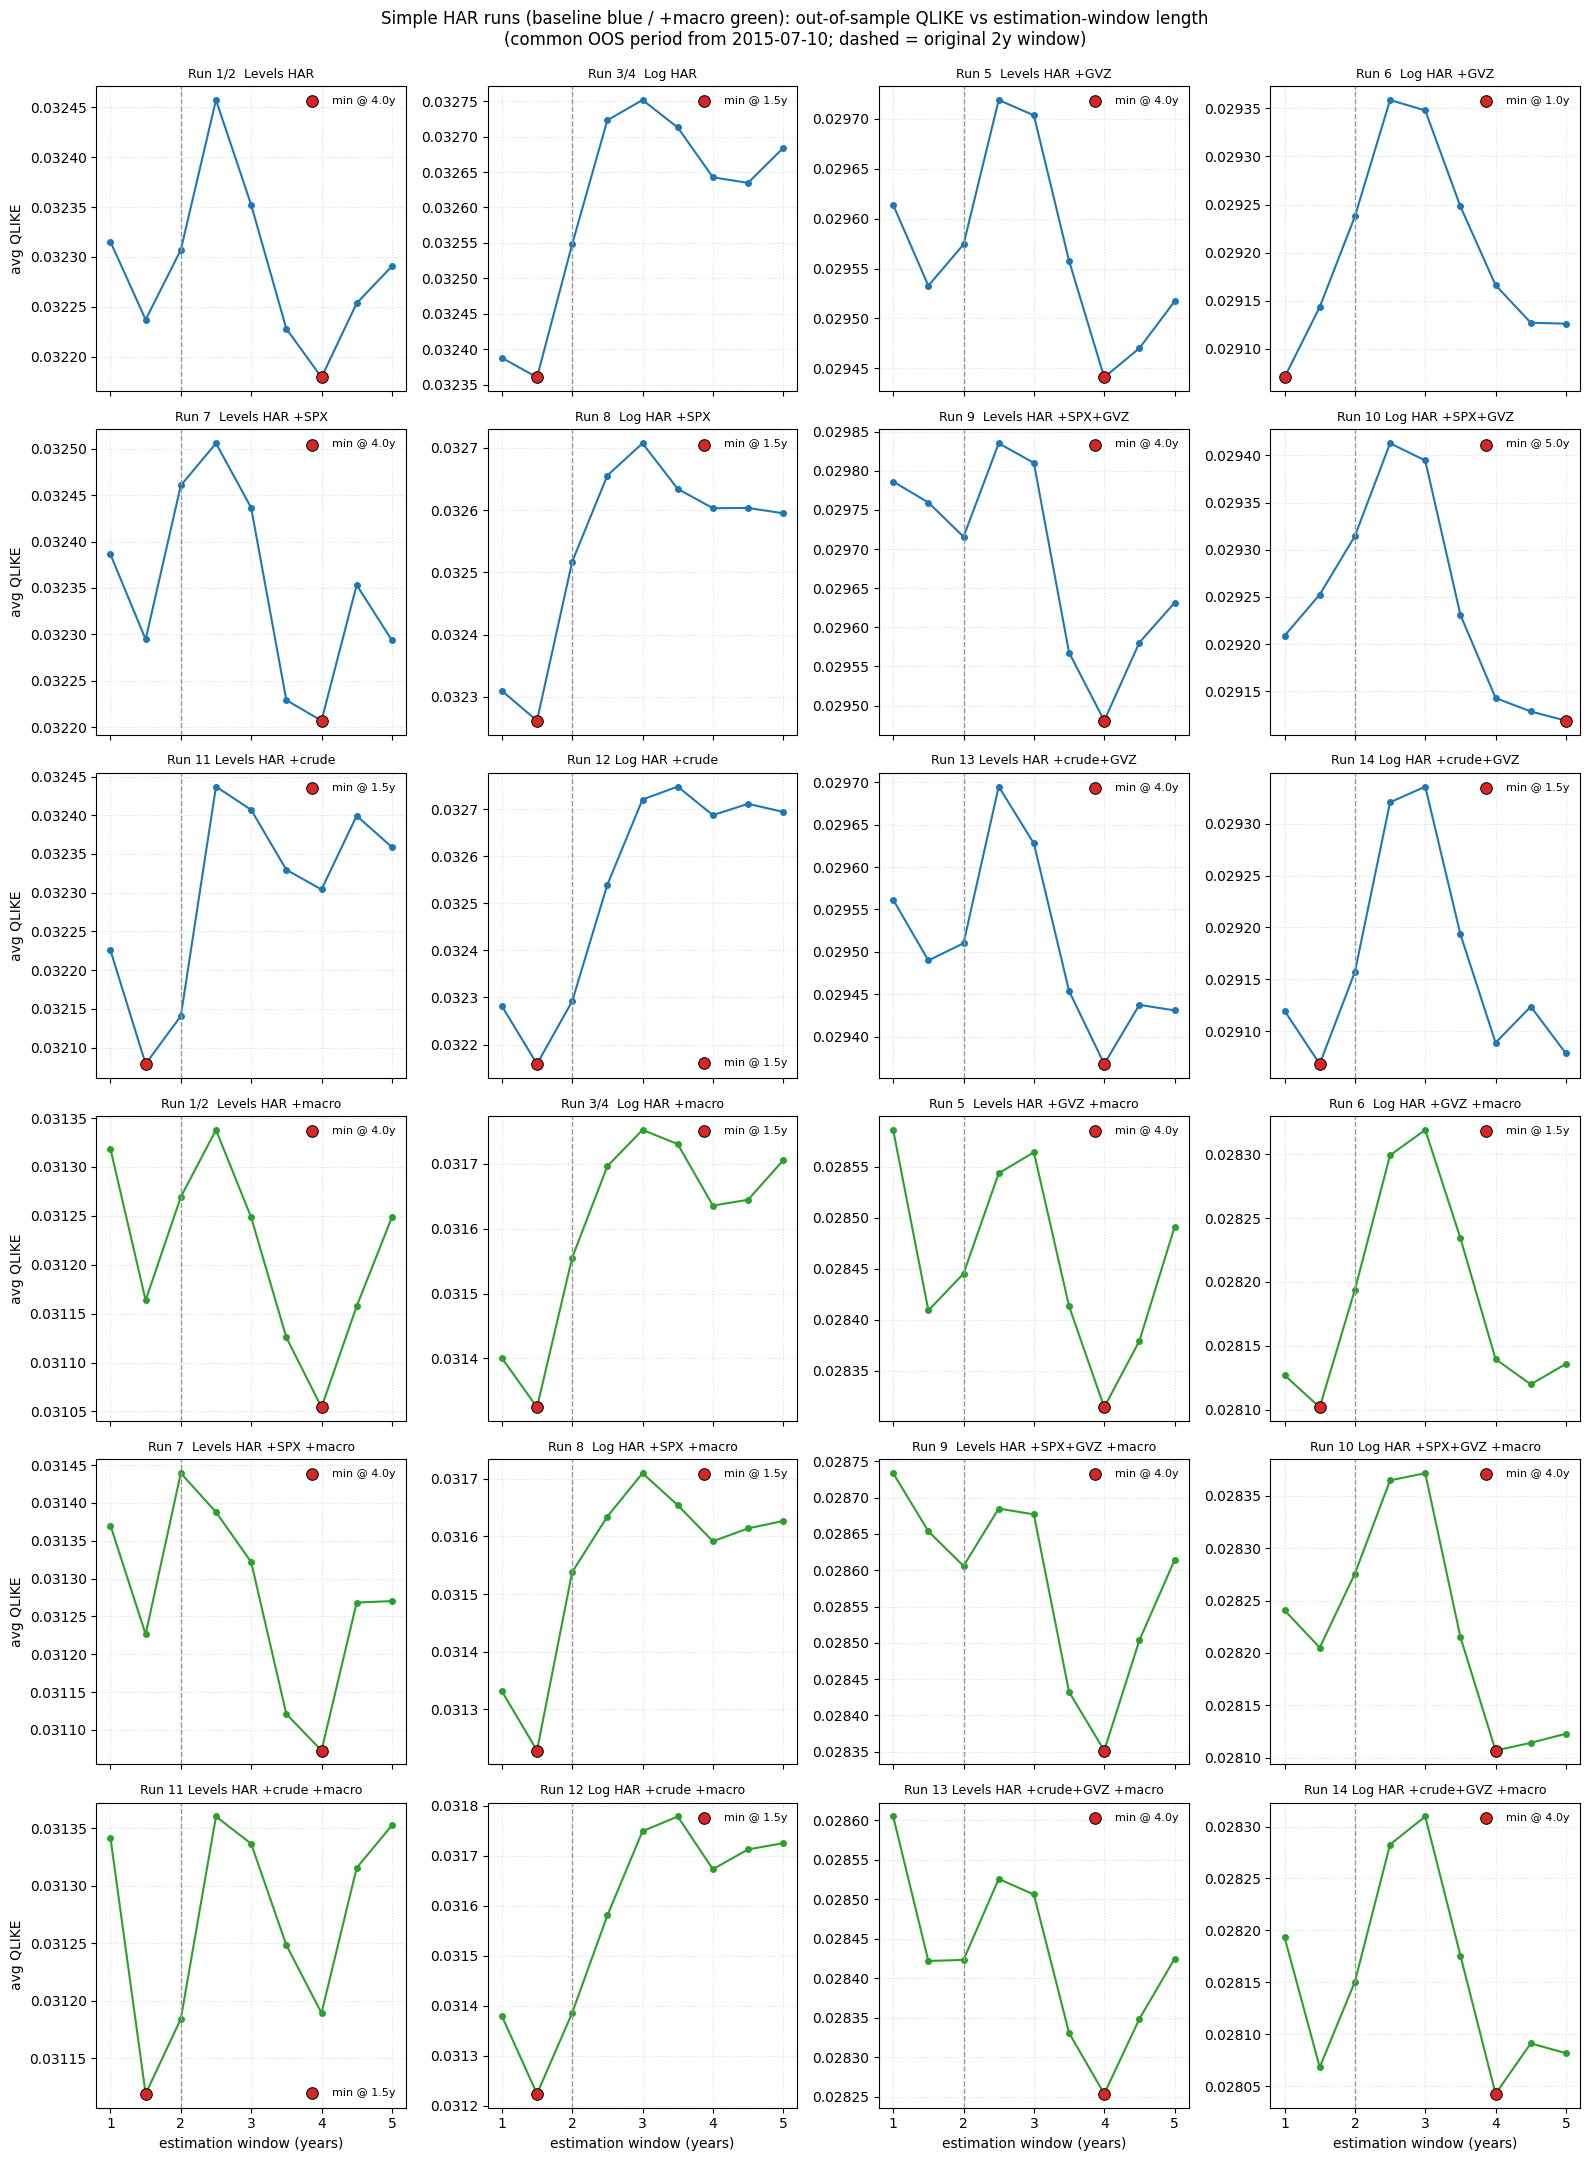

In [30]:
# ===========================================================================
# Cell 23 — Grid of per-run QLIKE-vs-window graphs (baseline + +macro)
# ===========================================================================
nrows, ncols = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 22), sharex=True)
for ax, label in zip(axes.ravel(), qlike_by_window.columns):
    col = qlike_by_window[label]
    color = "tab:green" if "+macro" in label else "tab:blue"
    ax.plot(WINDOW_YEARS, col.to_numpy(), marker="o", ms=4, color=color)
    ax.scatter([col.idxmin()], [col.min()], color="tab:red", s=70, zorder=5,
               edgecolor="black", linewidth=0.7, label=f"min @ {col.idxmin():.1f}y")
    ax.axvline(2.0, color="0.6", ls="--", lw=1)   # original ~500-day (2y) window
    ax.set_title(label, fontsize=9)
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(frameon=False, fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel("estimation window (years)")
for ax in axes[:, 0]:
    ax.set_ylabel("avg QLIKE")
for ax in axes.ravel()[len(qlike_by_window.columns):]:
    ax.set_visible(False)

fig.suptitle("Simple HAR runs (baseline blue / +macro green): out-of-sample QLIKE vs "
             f"estimation-window length\n(common OOS period from {start_date.date()}; "
             "dashed = original 2y window)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("qlike_vs_window_length_with_macro.png", dpi=150)
plt.show()


Basically proved that using the same evaluation period for all window lengths is important, as the shorter windows are more sensitive to the volatile 2010–13 period. The 1-year window is particularly poor in this regard, but even the 2-year window is noticeably worse than the 3-year and longer windows. 

In [31]:
# ===========================================================================
# Cell 24 — ALTERNATIVE window-length sweep: avg QLIKE over ALL observations
#           (NO common-OOS clip — each window keeps its own full forecast period)
# ===========================================================================
# Cell 22 scored every window over the SAME out-of-sample dates (from `start_date`, the first
# origin of the largest 5y window) to isolate window length from the test sample. Here we do the
# OPPOSITE: each window is scored over ALL of its own out-of-sample forecasts. A 1y window starts
# forecasting ~4 years earlier than a 5y window, so it is judged on more — and earlier — history.
#
# Why: if a longer window looks better in Cell 22, is that because more estimation data genuinely
# helps, or merely because the common-OOS clip DROPS the early periods where HAR forecasts badly?
# Comparing this full-sample QLIKE against the clipped `qlike_by_window` answers that. The
# non-`_eval` helpers from Cell 12 (`rolling_levels_qlike`, `rolling_log_qlike_smearing`) already
# loop `for t in range(window, len(design))` with no date filter — exactly what we want here.

qlike_by_window_full = pd.DataFrame(index=WINDOW_YEARS,
                                    columns=[s[0] for s in RUN_SPECS], dtype=float)
nfc_full = {}           # (label, yr) -> n_forecasts  (now varies by window)
for label, kind, design, feats in RUN_SPECS:
    for yr, w in zip(WINDOW_YEARS, WINDOWS):
        if kind == "lev":
            q, n, clip = rolling_levels_qlike(design, feats, "y", w)
        else:
            q, n, clip = rolling_log_qlike_smearing(design, feats, "y_log", "y_level", w)
        qlike_by_window_full.loc[yr, label] = q
        nfc_full[(label, yr)] = n
    print(f"{label:<28} swept {len(WINDOWS)} windows (full sample)")

# Per-window forecast-count range and earliest OOS origin date (across the distinct designs).
# These DIFFER by window here (unlike Cell 22) — that difference IS the clipping effect.
_designs_full = {id(d): d for (_, _, d, _) in RUN_SPECS}.values()
oos_period = pd.DataFrame(index=WINDOW_YEARS,
                          columns=["n_min", "n_max", "earliest_origin"])
for yr, w in zip(WINDOW_YEARS, WINDOWS):
    counts = [nfc_full[(lbl, yr)] for lbl in qlike_by_window_full.columns]
    earliest = min(d.index[w].date() for d in _designs_full)   # earliest origin scored at window w
    oos_period.loc[yr] = [min(counts), max(counts), earliest]

print(f"\nWindows (days): {WINDOWS}")
print("\nForecast count & earliest OOS origin per window (now VARIES — clip removed):")
print(oos_period.to_string())

print("\nFull-sample avg QLIKE by window length (rows = window years, cols = run):")
print(qlike_by_window_full.to_string(float_format=lambda v: f"{v:.6f}"))

print("\nQLIKE-minimising window per run (full sample):")
for label in qlike_by_window_full.columns:
    col = qlike_by_window_full[label]
    print(f"  {label:<28} best = {col.idxmin():.1f}y  (QLIKE {col.min():.6f}); 2.0y = {col.loc[2.0]:.6f}")

# Delta vs the common-OOS clip (Cell 22). full - clipped:
#   delta > 0  -> the extra (earlier) observations this window includes are HARDER than the
#                 common period, i.e. the clip in Cell 22 was hiding bad early-period forecasts.
#   delta ~ 0  -> window's full period ~ common period (true for the largest window).
delta = (qlike_by_window_full - qlike_by_window).astype(float)
print("\nDelta QLIKE (full-sample - common-OOS clip); positive = full sample is harder/worse:")
print(delta.to_string(float_format=lambda v: f"{v:+.6f}"))


Run 1/2  Levels HAR          swept 9 windows (full sample)


Run 3/4  Log HAR             swept 9 windows (full sample)


Run 5  Levels HAR +GVZ       swept 9 windows (full sample)


Run 6  Log HAR +GVZ          swept 9 windows (full sample)


Run 7  Levels HAR +SPX       swept 9 windows (full sample)


...

Run 10 Log HAR +SPX+GVZ +macro swept 9 windows (full sample)


Run 11 Levels HAR +crude +macro swept 9 windows (full sample)


Run 12 Log HAR +crude +macro swept 9 windows (full sample)


Run 13 Levels HAR +crude+GVZ +macro swept 9 windows (full sample)


Run 14 Log HAR +crude+GVZ +macro swept 9 windows (full sample)

Windows (days): [252, 378, 504, 630, 756, 882, 1008, 1134, 1260]

Forecast count & earliest OOS origin per window (now VARIES — clip removed):
         n_min n_max earliest_origin
1.000000  3741  3741      2011-07-07
1.500000  3615  3615      2012-01-05
2.000000  3489  3489      2012-07-06
2.500000  3363  3363      2013-01-08
3.000000  3237  3237      2013-07-10
3.500000  3111  3111      2014-01-08
4.000000  2985  2985      2014-07-10
4.500000  2859  2859      2015-01-08
5.000000  2733  2733      2015-07-10

Full-sample avg QLIKE by window length (rows = window years, cols = run):
          Run 1/2  Levels HAR  Run 3/4  Log HAR  Run 5  Levels HAR +GVZ  Run 6  Log HAR +GVZ  Run 7  Levels HAR +SPX  Run 8  Log HAR +SPX  Run 9  Levels HAR +SPX+GVZ  Run 10 Log HAR +SPX+GVZ  Run 11 Levels HAR +crude  Run 12 Log HAR +crude  Run 13 Levels HAR +crude+GVZ  Run 14 Log HAR +crude+GVZ  Run 1/2  Levels HAR +macro  Run 3/4  Log HAR +macr